In [58]:
%%writefile circuit_extract.py
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from copy import deepcopy

import utils

def visualize_circuit_masks(circuit, binarize=False):
    # 1. Extract and process masks
    # We zip with the model chain to know what layer type corresponds to what mask
    layers_data = []
    
    with torch.no_grad():
        for i, (mask_module, layer_module) in enumerate(zip(circuit.masks, circuit.model.chain)):
            name = str(layer_module).split('(')[0]
            
            # if "ReLU" in name or "MaxPool" in name:
            #     continue

            if not mask_module.active:
                continue

            mask = mask_module.mask.detach().cpu()
            temp = mask_module.temperature
            
            if binarize:
                prob = (mask > 0).float()
            else:
                prob = torch.sigmoid(mask / temp)
            
            layers_data.append({
                "index": i,
                "name": str(layer_module).split('(')[0], # e.g. Conv2d, ReLU
                "prob": prob,
                "type": "conv" if prob.dim() > 1 else ("fc" if prob.numel() < 100 else "flat")
            })

    # 2. Filter data for plotting
    conv_layers = [l for l in layers_data if l["type"] == "conv"]
    fc_layers =   [l for l in layers_data if l["type"] == "fc"]

    # 3. Setup Figure
    # We create a Grid with 2 Rows: Top for Conv, Bottom for FC
    num_conv = len(conv_layers)
    num_fc = len(fc_layers)
    
    # If no layers of a certain type exist, handle gracefully
    if num_conv == 0 and num_fc == 0:
        print("No masks found to visualize.")
        return

    # Create figure with dynamic width based on number of layers
    total_cols = max(num_conv, num_fc)
    fig = plt.figure(figsize=(max(4, total_cols * 2.5), 10))
    fig.suptitle(f'Circuit Signal Propagation\n(Lighter = Kept, Darker = Pruned)', fontsize=16)

    # --- Plot Convolutional Layers (Row 1) ---
    if num_conv > 0:
        # Create subplots for the first row
        # usage: subplot(rows, cols, index)
        for idx, layer in enumerate(conv_layers):
            ax = fig.add_subplot(2, num_conv, idx + 1)
            
            # Calculate mean activation per channel: (C, H, W) -> (C, 1)
            # dim=list(range(1, prob.dim())) usually [1, 2] for (C, H, W)
            spatial_dims = list(range(1, layer["prob"].dim()))
            channel_activity = layer["prob"].mean(dim=spatial_dims).numpy().reshape(-1, 1)
            
            sns.heatmap(
                channel_activity, 
                ax=ax, 
                cmap="viridis", 
                vmin=0, vmax=1, 
                cbar=(idx == num_conv - 1), # Only show colorbar on last plot
                xticklabels=False,
                yticklabels=True
            )
            
            ax.set_title(f'L{layer["index"]}: {layer["name"]}\n(Channels: {channel_activity.shape[0]})')
            ax.set_ylabel('Channel Index')
            ax.set_xlabel('Avg Activity')

    # --- Plot Fully Connected Layers (Row 2) ---
    if num_fc > 0:
        # Center the FC plots if there are fewer than Conv plots
        start_offset = 0
        
        for idx, layer in enumerate(fc_layers):
            # Plot in the second row
            ax = fig.add_subplot(2, num_fc, num_fc + idx + 1)
            
            neuron_activity = layer["prob"].numpy().reshape(-1, 1)
            
            sns.heatmap(
                neuron_activity, 
                ax=ax, 
                cmap="magma", # Different colormap to distinguish FC
                vmin=0, vmax=1, 
                cbar=(idx == num_fc - 1),
                xticklabels=False,
                yticklabels=True,
                annot=True, # Show numbers for FC neurons since they are few
                fmt=".2f"
            )
            
            ax.set_title(f'L{layer["index"]}: {layer["name"]}\n(Neurons: {neuron_activity.shape[0]})')
            ax.set_ylabel('Neuron Index')
            ax.set_xlabel('Activity')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust for suptitle
    
    output_path = "out/circuit_visualization.png"
    plt.savefig(output_path)
    plt.show()
    print(f"\nVisualization saved to {output_path}")

# def analyze_disconnected_unmasked(circuit, threshold_weight=0.1, threshold_mask=0.5):
#     """
#     Identifies and visualizes 'Zombie' units: Channels/Neurons that are 
#     kept active by the mask (unmasked) but have near-zero weights (disconnected).
#     """
#     print(f" Analysis: Disconnected vs Unmasked ")
    
#     zombies = []

#     # Based on inference.CNN structure:
#     weight_layers = {
#         0: "Conv 1",
#         3: "Conv 2",
#         7: "Classifier (Linear)"
#     }

#     fig, axes = plt.subplots(1, 3, figsize=(18, 5))
#     fig.suptitle("Weight Magnitude vs. Mask Activation\n(Top-Left Quadrant = Disconnected yet Unmasked)", fontsize=16)

#     for idx, (layer_idx, layer_name) in enumerate(weight_layers.items()):
#         # 1. Get Mask Data
#         # Mask is on the OUTPUT of the layer.
#         mask_module = circuit.masks[layer_idx]

#         # Calculate Mean Mask Value per Channel/Unit
#         with torch.no_grad():
#             mask_val = torch.sigmoid(mask_module.mask / mask_module.temperature).cpu()
            
#             if mask_val.dim() > 1: # Conv Layer: (C, H, W) -> Average over H,W to get (C)
#                 mask_scores = mask_val.mean(dim=[1, 2])
#             else: # Linear Layer: (C)
#                 mask_scores = mask_val

#             # 2. Get Weight Data
#             layer_module = circuit.model.chain[layer_idx]
#             weights = layer_module.weight.data.cpu() # Shape: (Out, In, k, k) or (Out, In)
            
#             # Calculate L2 Norm of filters producing these outputs
#             # Flatten all dims except the first (Out Channels)
#             weight_norms = weights.view(weights.shape[0], -1).norm(dim=1)

#         # 3. Identify Zombies
#         # Unmasked (Mask > 0.5) AND Disconnected (Weight < threshold)
#         is_unmasked = mask_scores > threshold_mask
#         is_disconnected = weight_norms < threshold_weight
#         zombie_indices = torch.where(is_unmasked & is_disconnected)[0]
        
#         if len(zombie_indices) > 0:
#             zombies.append(f"{layer_name}: {len(zombie_indices)} units (Indices: {zombie_indices.tolist()})")

#         # 4. Plot
#         ax = axes[idx]
#         ax.scatter(weight_norms, mask_scores, alpha=0.6, c=mask_scores, cmap='viridis')
        
#         # Add "Zombie Zone" highlighting
#         ax.axhspan(ymin=threshold_mask, ymax=1.1, xmin=0, xmax=threshold_weight/max(weight_norms), 
#                    color='red', alpha=0.1, label='Zombie Zone')
        
#         ax.set_title(f"{layer_name}\n({weights.shape[0]} units)")
#         ax.set_xlabel("Weight L2 Norm (Connection Strength)")
#         ax.set_ylabel("Mask Probability (Keep Strength)")
#         ax.grid(True, linestyle='--', alpha=0.5)
        
#         # Annotate specific points if they are zombies
#         for z_idx in zombie_indices:
#              ax.text(weight_norms[z_idx], mask_scores[z_idx], str(z_idx.item()), fontsize=8)

#     plt.tight_layout(rect=[0, 0.03, 1, 0.95])
#     plt.show()
    
#     print("Potential 'Zombie' Units found:")
#     for z in zombies:
#         print(f" - {z}")
#     if not zombies:
#         print(" - None found (All kept units have significant weights)")
        
#     return zombies

#hmmm this fn only looks at a layer and averages over channels (Imma try something more granular)
def analyze_circuit_overlay(circuits_dict, layer_idx=3):
    """
    Visualizes the intersection of neurons across multiple class circuits.
    
    
    circuits_dict: {class_label: circuit_model}
    layer_idx: layer -> analyze
    """
    print(f" Analysis: Circuit Overlay (Layer {layer_idx}) ")

    labels = list(circuits_dict.keys())
    
    # 1. Collect Masks
    mask_collection = []
    
    for label, circ in circuits_dict.items():
        with torch.no_grad():
            mask_module = circ.masks[layer_idx]
            # Get binary mask decision (soft > 0.5) or raw probability
            prob = torch.sigmoid(mask_module.mask / mask_module.temperature).cpu()
            
            # Collapse spatial dims if conv layer to get Channel Importance
            if prob.dim() > 1:
                # Average over spatial dimensions to get score per channel
                # Shape: (Num_Channels)
                channel_score = prob.mean(dim=[1, 2])
            else:
                channel_score = prob
                
            mask_collection.append(channel_score.numpy())

    # Shape: (Num_Classes, Num_Channels)
    heatmap_data = np.stack(mask_collection)
    
    # 2. Visualize Overlay
    plt.figure(figsize=(12, max(4, len(labels)/2)))
    
    # Plot heatmap
    ax = sns.heatmap(
        heatmap_data, 
        yticklabels=[f"Class {l}" for l in labels],
        xticklabels=True,
        cmap="magma", 
        vmin=0, vmax=1,
        annot=False
    )
    
    plt.title(f"Neuron Commonality Map - Layer {layer_idx}\n(Vertical stripes = Shared Features)")
    plt.xlabel("Neuron/Channel Index")
    plt.ylabel("Circuit Class")
    plt.show()
    
    # 3. Compute Intersection Statistics
    # Binarize to find strict overlap
    binary_map = heatmap_data > 0.5
    
    # Sum down the columns (how many classes use channel X?)
    usage_counts = binary_map.sum(axis=0)
    
    shared_neurons = np.where(usage_counts == len(labels))[0]
    unique_neurons = np.where(usage_counts == 1)[0]
    
    print(f"Layer {layer_idx} Stats:")
    print(f" - Total Neurons/Channels: {len(usage_counts)}")
    print(f" - Universally Shared Neurons (Used by all): {len(shared_neurons)} indices: {shared_neurons}")
    print(f" - Class-Specific Neurons (Used by exactly 1): {len(unique_neurons)}")
    
    return shared_neurons

Overwriting circuit_extract.py


In [59]:
%%writefile colour_mnist.py
"""ReBias
Copyright (c) 2020-present NAVER Corp.
MIT license

Python implementation of Biased-MNIST.
"""
import os
import numpy as np
from PIL import Image

import torch
from torch.utils import data

from torchvision import transforms
from torchvision.datasets import MNIST


class BiasedMNIST(MNIST):
    """A base class for Biased-MNIST.
    We manually select ten colours to synthetic colour bias. (See `COLOUR_MAP` for the colour configuration)
    Usage is exactly same as torchvision MNIST dataset class.

    You have two paramters to control the level of bias.

    Parameters
    ----------
    root : str
        path to MNIST dataset.
    data_label_correlation : float, default=1.0
        Here, each class has the pre-defined colour (bias).
        data_label_correlation, or `rho` controls the level of the dataset bias.

        A sample is coloured with
            - the pre-defined colour with probability `rho`,
            - coloured with one of the other colours with probability `1 - rho`.
              The number of ``other colours'' is controlled by `n_confusing_labels` (default: 9).
        Note that the colour is injected into the background of the image (see `_binary_to_colour`).

        Hence, we have
            - Perfectly biased dataset with rho=1.0
            - Perfectly unbiased with rho=0.1 (1/10) ==> our ``unbiased'' setting in the test time.
        In the paper, we explore the high correlations but with small hints, e.g., rho=0.999.

    n_confusing_labels : int, default=9
        In the real-world cases, biases are not equally distributed, but highly unbalanced.
        We mimic the unbalanced biases by changing the number of confusing colours for each class.
        In the paper, we use n_confusing_labels=9, i.e., during training, the model can observe
        all colours for each class. However, you can make the problem harder by setting smaller n_confusing_labels, e.g., 2.
        We suggest to researchers considering this benchmark for future researches.
    """

    COLOUR_MAP = [[255, 0, 0], [0, 255, 0], [0, 0, 255], [225, 225, 0], [225, 0, 225],
                  [0, 255, 255], [255, 128, 0], [255, 0, 128], [128, 0, 255], [128, 128, 128]]

    def __init__(self, root, train=True, transform=None, target_transform=None,
                 download=False, data_label_correlation=1.0, n_confusing_labels=9):
        super().__init__(root, train=train, transform=transform,
                         target_transform=target_transform,
                         download=download)
        self.random = True

        self.data_label_correlation = data_label_correlation
        self.n_confusing_labels = n_confusing_labels
        self.data, self.targets, self.biased_targets = self.build_biased_mnist()

        indices = np.arange(len(self.data))
        self._shuffle(indices)

        self.data = self.data[indices].numpy()
        self.targets = self.targets[indices]
        self.biased_targets = self.biased_targets[indices]

    @property
    def raw_folder(self):
        return os.path.join(self.root, 'raw')

    @property
    def processed_folder(self):
        return os.path.join(self.root, 'processed')

    def _shuffle(self, iteratable):
        if self.random:
            np.random.shuffle(iteratable)

    def _make_biased_mnist(self, indices, label):
        raise NotImplementedError

    def _update_bias_indices(self, bias_indices, label):
        if self.n_confusing_labels > 9 or self.n_confusing_labels < 1:
            raise ValueError(self.n_confusing_labels)

        indices = np.where((self.targets == label).numpy())[0]
        self._shuffle(indices)
        indices = torch.LongTensor(indices)

        n_samples = len(indices)
        n_correlated_samples = int(n_samples * self.data_label_correlation)
        n_decorrelated_per_class = int(np.ceil((n_samples - n_correlated_samples) / (self.n_confusing_labels)))

        correlated_indices = indices[:n_correlated_samples]
        bias_indices[label] = torch.cat([bias_indices[label], correlated_indices])

        decorrelated_indices = torch.split(indices[n_correlated_samples:], n_decorrelated_per_class)

        other_labels = [_label % 10 for _label in range(label + 1, label + 1 + self.n_confusing_labels)]
        self._shuffle(other_labels)

        for idx, _indices in enumerate(decorrelated_indices):
            _label = other_labels[idx]
            bias_indices[_label] = torch.cat([bias_indices[_label], _indices])

    def build_biased_mnist(self):
        """Build biased MNIST.
        """
        n_labels = self.targets.max().item() + 1

        bias_indices = {label: torch.LongTensor() for label in range(n_labels)}
        for label in range(n_labels):
            self._update_bias_indices(bias_indices, label)

        data = torch.ByteTensor()
        targets = torch.LongTensor()
        biased_targets = []

        for bias_label, indices in bias_indices.items():
            _data, _targets = self._make_biased_mnist(indices, bias_label)
            data = torch.cat([data, _data])
            targets = torch.cat([targets, _targets])
            biased_targets.extend([bias_label] * len(indices))

        biased_targets = torch.LongTensor(biased_targets)
        return data, targets, biased_targets

    def __getitem__(self, index):
        img, target = self.data[index], int(self.targets[index])
        img = Image.fromarray(img.astype(np.uint8), mode='RGB')

        if self.transform is not None:
            img = self.transform(img)

        if self.target_transform is not None:
            target = self.target_transform(target)

        return img, target, int(self.biased_targets[index])


class ColourBiasedMNIST(BiasedMNIST):
    def __init__(self, root, train=True, transform=None, target_transform=None,
                 download=False, data_label_correlation=1.0, n_confusing_labels=9):
        super(ColourBiasedMNIST, self).__init__(root, train=train, transform=transform,
                                                target_transform=target_transform,
                                                download=download,
                                                data_label_correlation=data_label_correlation,
                                                n_confusing_labels=n_confusing_labels)

    def _binary_to_colour(self, data, colour):
        fg_data = torch.zeros_like(data)
        fg_data[data != 0] = 255
        fg_data[data == 0] = 0
        fg_data = torch.stack([fg_data, fg_data, fg_data], dim=1)

        bg_data = torch.zeros_like(data)
        bg_data[data == 0] = 1
        bg_data[data != 0] = 0
        bg_data = torch.stack([bg_data, bg_data, bg_data], dim=3)
        bg_data = bg_data * torch.ByteTensor(colour)
        bg_data = bg_data.permute(0, 3, 1, 2)

        data = fg_data + bg_data
        return data.permute(0, 2, 3, 1)

    def _make_biased_mnist(self, indices, label):
        return self._binary_to_colour(self.data[indices], self.COLOUR_MAP[label]), self.targets[indices]


def get_biased_mnist_dataloader(root, batch_size, data_label_correlation,
                                n_confusing_labels=9, train=True, num_workers=8):
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=(0.5, 0.5, 0.5),
                             std=(0.5, 0.5, 0.5))])
    dataset = ColourBiasedMNIST(root, train=train, transform=transform,
                                download=True, data_label_correlation=data_label_correlation,
                                n_confusing_labels=n_confusing_labels)
    dataloader = data.DataLoader(dataset=dataset,
                                 batch_size=batch_size,
                                 shuffle=True,
                                 num_workers=num_workers,
                                 pin_memory=True)
    return dataloader


Overwriting colour_mnist.py


In [60]:
%%writefile inference.py
import torch
from torch import nn

class CNN(nn.Module):
    def __init__(self, nc: int, nf: int, num_classes: int, inp_shape: list[int]):
        super(CNN, self).__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(nc, nf, kernel_size=3, padding=1, bias=False),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(nf, 2*nf, kernel_size=3, padding=1, bias=False),
            nn.ReLU(), 
            nn.MaxPool2d(2),
            nn.Flatten()
        )
     
        dummy_input = torch.randn(1,*inp_shape)
        with torch.no_grad():
            inp_flat = self.encoder(dummy_input).numel()

        hidden_dim = max(inp_flat//2, num_classes)
        self.classifier = nn.Sequential(
            # nn.Linear(inp_flat, hidden_dim, bias=False),
            # nn.ReLU(),
            # nn.Linear(hidden_dim, num_classes, bias=False)
            nn.Linear(inp_flat, num_classes, bias=False)
        )

        self.chain = nn.ModuleList([*self.encoder, *self.classifier])

    def forward(self, x):
        x = self.encoder(x)
        x = self.classifier(x)
        return x
    


class Prune(torch.autograd.Function):   
    @staticmethod
    def forward(ctx, mask_param, temperature):
        ctx.save_for_backward(mask_param)
        ctx.temperature = temperature
        return (mask_param > 0).float()

    @staticmethod
    def backward(ctx, grad_output):
        mask_param, = ctx.saved_tensors
        temp = ctx.temperature
        
        sig = torch.sigmoid(mask_param / temp)
        grad_sigmoid = (1 / temp) * sig * (1 - sig)
        return grad_output * grad_sigmoid, None
    


class Mask(nn.Module):
    def __init__(self, inp_shape: list[int], temperature: float, mean_act: torch.Tensor, active: bool = True):
        super().__init__()
        self.active = active
        self.temperature = temperature

        self.register_buffer('mean_act', mean_act.detach())

        init_val = torch.normal(1, 0.1, size=inp_shape) if active else torch.ones(size=inp_shape)
        self.mask = nn.Parameter(init_val, requires_grad=active)

        self.cached_mask = None

    def forward(self, x, mean_ablation=False):
        self.cached_mask = mask = Prune.apply(self.mask, self.temperature)
        out = x*mask
        if mean_ablation:
            out += (1 - mask)*self.mean_act 

        return out
    
    def clamp(self):
        with torch.no_grad():
            self.mask.clamp_(min=-1, max=1)
        
    def l0_loss(self):
        return torch.sum(self.cached_mask) if self.active else 0



class Circuit(nn.Module):
    def __init__(self, model: nn.Module, inp_shape: list[int], mean_activations: list[torch.Tensor], temperature:float=0.3, mean_ablation=True):
        super().__init__()
        
        self.model = model
        for p in self.model.parameters():
            p.requires_grad = False
        
        self.mean_activations = mean_activations
        self.masks = nn.ModuleList([])
        self.temperature = temperature
        self.mean_ablation = mean_ablation
        self.total_params = 0
        dummy_input = torch.randn(1, *inp_shape).to(next(model.parameters()).device)
        self.cache = []

        
        assert len(mean_activations) == len(model.chain)

        with torch.no_grad():
            for mean_act, module in zip(mean_activations, model.chain):
                dummy_input = module(dummy_input)
                active = isinstance(module, nn.Conv2d)
                self.total_params += active*dummy_input.numel()

                self.masks.append(Mask(dummy_input.shape[1:], temperature=temperature, mean_act=mean_act, active=active))
                
 
    def forward(self, x, cache=False):
        self.cache.clear()
        for mask, module in zip(self.masks, self.model.chain):
            x = mask(module(x), self.mean_ablation)
            if cache:
                self.cache.append(x)
        return x
    
    def clamp_masks(self):
        for mask in self.masks:
            mask.clamp()
    
    def total_l0_loss(self):
        return sum(m.l0_loss() for m in self.masks if m.active)
    
    def debug_stats(self):
        with torch.no_grad():
            avg_mask = torch.mean(torch.stack([m.mask.mean() for m in self.masks if m.active]))
            return avg_mask.item()



Overwriting inference.py


In [61]:
%%writefile train.py
import random
from functools import partial

import numpy as np
import torch
import torch.nn.functional as F
import torchvision
from torchvision.transforms import v2
import inference
import typing
import colour_mnist

from torch import nn
from torch.utils.data import DataLoader, Subset


def acc(model: nn.Module, loader: DataLoader, device: torch.device):
    model.eval()
    model.to(device)

    correct = 0
    total = 0
    with torch.no_grad():
        for X,Y in loader:
            X, Y = X.to(device), Y.to(device)
            logits = model(X)
            correct += torch.sum(logits.argmax(dim=1) == Y)
            total += len(Y)

    return correct/total

#added a min_alive parameter which retains some amout of neurons in each filter
def topk(x, k, abs=False, dim=None, min_alive=4):   
    if k >= x.numel(): k = x.numel()

    topk_fn = partial(torch.topk, sorted=False)
    
    if dim is None or len(x.shape)==1:  
        x = x.flatten()
        topk_fn = partial(topk_fn, dim=0)
    else:
        sz = x.numel() // x.shape[dim]
        assert k % x.shape[dim] == 0

        def _topk_fn(x, k, topk_fn):
            k = max(min_alive, k//x.shape[dim])
            inds = torch.arange(x.numel()).reshape(x.shape)
            inds = inds.transpose(dim, 0).reshape(x.shape[dim], -1)
            vals = x.transpose(dim, 0).reshape(x.shape[dim], -1)
            vals, i = topk_fn(vals, dim=1, k=k, sorted=False)
            inds = torch.gather(inds, 1, i).flatten()
            
            return vals, inds

        topk_fn = partial(_topk_fn, topk_fn=topk_fn)

    if abs:
        _, inds = topk_fn(x.abs(), k)
        vals = x.flatten()[inds]
    else:
        vals, inds = topk_fn(x, k)

    return vals, inds


def apply_topk_(model, pfrac, min_alive=5):
  
    with torch.no_grad():
        for pn, p in model.named_parameters():
            k = int(pfrac * p.numel())
           
            if type(p) == nn.Conv2d:
                #we prune per filter 
                _, indices = topk(p.data.abs(), k=k, abs=False, dim=0, min_alive=min_alive)
                
            else:
                #we prune globally
                _, indices = topk(p.data, k=k, abs=False, dim=None, min_alive=min_alive)
            
            mask = torch.zeros_like(p.data.flatten(), dtype=torch.bool)
            mask.index_fill_(0, indices, 1)
            mask = mask.view_as(p.data)
            p.data[~mask] = 0 


def calculate_mean_activations(model, loader, device):
    model.eval()
    model.to(device)

    dummy_input, _ = next(iter(loader))
    dummy_input = dummy_input[0:1].to(device)
    acts = []

    with torch.no_grad():
        x = dummy_input
        for module in model.chain:
            x = module(x)
            acts.append(torch.zeros_like(x))

        count = 0
        for X, _ in loader:
            X = X.to(device)
            bs = X.shape[0]
            count += bs
            for i, module in enumerate(model.chain):
                X = module(X)
                acts[i] += X.sum(dim=0)
    
    return [act / count for act in acts]

#added a resampler
from typing import Any, Sequence

def resampler(labels: Sequence[Any], class_probs: dict[Any, float], n: int) -> list[int]:
    classes = np.unique(labels)

    class_idxs = {cls: [] for cls in classes}

    for idx, cls in enumerate(labels):
        class_idxs[cls].append(idx)
    
    for v in class_idxs.values():
        random.shuffle(v)

    ret: list[int] = []
    for cls in classes:
        idxs, prob = class_idxs[cls], class_probs[cls]
        ret += idxs[:int(prob * n)]

    return ret

def load_dataset(ds_name):
    transform=v2.Compose([
            v2.ToTensor(),
            v2.Normalize((0.1307,), (0.3081,))
        ])
    if ds_name == "mnist-baseline":
    
        trainset = torchvision.datasets.MNIST(root="./data",train=True, transform=transform, download=True)
        testset  = torchvision.datasets.MNIST(root="./data",train=False, transform=transform, download=True)

    elif "mnist-circuit" in ds_name:
        label = int(ds_name[-1])
        target_transform = lambda x: x==label
      
        testset  = torchvision.datasets.MNIST(root="./data",train=False, transform=transform, download=True, target_transform=target_transform)


          
        trainset_super = torchvision.datasets.MNIST(
            root="./data", 
            train=True, 
            transform=transform, 
            download=True
        )

        labs = (trainset_super.targets == label) 
        probs = {0: 0.5, 1: 0.5}

        train_idxs = resampler(labs.tolist(), probs, n=10000)
        trainset = Subset(trainset_super, train_idxs)
        
        # trainset = torchvision.datasets.MNIST(root="./data",train=True, transform=transform, download=True, target_transform=target_transform)
        # testset  = torchvision.datasets.MNIST(root="./data",train=False, transform=transform, download=True, target_transform=target_transform)
    
    elif "mnist-class" in ds_name:
      
        label = int(ds_name[-1])
        dataset = torchvision.datasets.MNIST(root="./data",transform=transform, download=True)
        train_idxs = torch.arange(len(dataset.train_labels))[dataset.train_labels == label]
        test_idxs  = torch.arange(len(dataset.test_labels))[dataset.test_labels == label]

        trainset = Subset(dataset, train_idxs)
        testset = Subset(dataset, test_idxs)


    elif "custom" in ds_name:
        label = int(ds_name[-1])
      
        testset  = torchvision.datasets.MNIST(root="./data",train=False, transform=transform, download=True)

        trainset_super = torchvision.datasets.MNIST(
            root="./data", 
            train=True, 
            transform=transform, 
            download=True
        )

        labs = trainset_super.targets
        probs = {}
        for i in range(10):
            probs[i] = 0.5/9
        probs[label] = 0.5

        train_idxs = resampler(labs.tolist(), probs, n=10000)
        trainset = Subset(trainset_super, train_idxs)
    elif "colour" in ds_name:
        trainloader = colour_mnist.get_biased_mnist_dataloader(root="./data", batch_size=128, data_label_correlation=0.99, train=True, num_workers=16)
        testloader = colour_mnist.get_biased_mnist_dataloader(root="./data", batch_size=128, data_label_correlation=0.99, train=False, num_workers=16)
    
    else:
        raise NotImplementedError
        


    trainloader = DataLoader(trainset, batch_size=128, shuffle=True, pin_memory=True,num_workers=16)
    testloader = DataLoader(testset, batch_size=128, shuffle=False, pin_memory=True,num_workers=16)

    return trainloader, testloader

# def finetune(
#     model: nn.Module,
#     num_classes: int,
#     lr: float,
#     b1: float,
#     b2: float,
#     ds_name: str,
#     eps : float,
#     epochs : int,
#     device : str,
#     seed: int = 0,
# ):

#     for p in model.parameters():
#         p.requires_grad = False

#     in_features = model.fc.in_features
#     model.fc = torch.nn.Linear(in_features, num_classes)
#     model.fc.requires_grad = True

#     all_params = list(model.fc.parameters())

#     train_model(model, lr, b1, b2, None, ds_name, eps, epochs, device, all_params, seed)


def train_model(
    model: nn.Module,
    lr: float,
    b1: float,
    b2: float,
    # pfrac: float | None,
    ds_name: str,
    eps : float,
    epochs : int,
    device : str,
    scheduler: typing.Callable[[int], float] | None,
    all_params: list = None,
    seed: int = 0,
):
  
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    
    if all_params is None: all_params = list(model.parameters())
    betas = (b1, b2)

    optimizer = torch.optim.Adam(
        all_params,
        lr=lr,
        eps=eps,
        betas=betas,
        fused=True,
    )

    trainloader, testloader = load_dataset(ds_name)

    n_params = sum(p.numel() for p in model.parameters())
    n_params_wd = sum(p.numel() for p in model.parameters() if len(p.shape) > 1)

    print("n_params", n_params, "n_params_wd", n_params_wd)

    model.train()
    model.to(device)
    print(device)
    for epoch in range(epochs):
        for X, Y in trainloader:
            X, Y = X.to(device), Y.to(device)

            optimizer.zero_grad()
            logits = model(X)
            loss = F.cross_entropy(logits, Y)
            loss.backward()
            optimizer.step()

            if scheduler is not None:
                pfrac = scheduler(epoch+1) 
                apply_topk_(
                    model,
                    pfrac=pfrac,
                )


            if pfrac is not None:    
                apply_topk_(
                    model,
                    pfrac=pfrac,
                )

        if epoch % 1 == 0:
            print(f'Epoch {epoch} | Train Acc: {acc(model, trainloader, device):.4f} | Test Acc: {acc(model, testloader, device):.4f}')


def extract_circuit(
        model:nn.Module, 
        lr: float, 
        b1: float, 
        b2: float, 
        ds_name: str, 
        eps: float, 
        epochs: int, 
        device: torch.device = 'cpu', 
        l0_lambda: float = 0.0, 
        temperature:float =0.3,
        mean_ablation: bool = True,
        seed=0
    ):
    
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    model.eval()
    model.to(device)
    
    trainloader, testloader = load_dataset(ds_name)
    inp_shape = next(iter(trainloader))[0][0].shape # (C, H, W)

    print("Calculating mean activations...")
    mean_activations = calculate_mean_activations(model, load_dataset("mnist-baseline")[0], device)
    
    print("Initializing Circuit...")
    circuit = inference.Circuit(model, inp_shape, mean_activations, temperature, mean_ablation)
    circuit.to(device)

    print("Initializing Optimizer...")
    optimizer = torch.optim.Adam(circuit.parameters(), lr=lr, eps=eps, betas=(b1, b2))

   
    print(f"Extracting Circuit (L0 Lambda={l0_lambda})...")
    for epoch in range(epochs):
        circuit.train() 
        circuit.model.eval()
        total_loss_avg = 0
        
        for X, Y in trainloader:

            X, Y = X.to(device), Y.to(device)

            optimizer.zero_grad()
            logits = circuit(X)
            
            ce_loss = F.cross_entropy(logits, Y)
            epsilon = 1e-4
            l0_loss = circuit.total_l0_loss()/circuit.total_params+epsilon
            
            loss = (ce_loss + l0_lambda * l0_loss)
            
            loss.backward()
            optimizer.step()
            circuit.clamp_masks()
            
            total_loss_avg += loss.item()

        if epoch % 1 == 0:
            mask_avg = circuit.debug_stats()
            print(f'Epoch {epoch} | Loss: {total_loss_avg/len(trainloader):.4f} | Avg Mask: {mask_avg:.3f} | Total Non-Zero: {circuit.total_l0_loss()} | | Circuit Acc: {acc(circuit, testloader, device):.4f}')

    return circuit

Overwriting train.py


In [62]:
%%writefile utils.py
import torch
import train
from copy import deepcopy
import circuit_extract as ce
import inference as inf
import matplotlib.pyplot as plt
import torch.nn.functional as F
import numpy as np
import seaborn as sns

EPSILON = 1e-8

def scheduler(start, end, start_sparsity, target_sparsity, alpha):
    def f(epochs):
        t = min(max(0, epochs-start), end-start)/ (end-start)
        t = t**alpha
        return (target_sparsity* t + (1-t) * start_sparsity)
    return f

#added an optional parameter
def run_class_circuit(class_idx: int, model, epochs=9, l0_lambda=0.05, lr=1e-3, mean_ablation=True, seed=42):
    """
    Extracts and visualizes a circuit for a specific target class (0-9).
    """
    print(f" Processing Class {class_idx} ")
    
    ds_name = f"mnist-class-{class_idx}"
    
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    print(f"Configuration: Device={device}, Lambda={l0_lambda}, Dataset={ds_name}")

    circuit = train.extract_circuit(
        model=deepcopy(model),
        lr=lr,
        b1=0.9, b2=0.999,
        ds_name=ds_name,     
        eps=1e-8,
        epochs=epochs,
        device=device,
        l0_lambda=l0_lambda,
        seed=seed,
        mean_ablation=mean_ablation
    )

    print(f"\n--- Visualizing Circuit for Class {class_idx} ---")
    
    try:
        ce.visualize_circuit_masks(circuit) 
        
        import os
        if os.path.exists("out/circuit_visualization.png"):
            os.rename("out/circuit_visualization.png", f"out/circuit_viz_class_{class_idx}.png")
            print(f"Saved visualization to: out/circuit_viz_class_{class_idx}.png")
            
    except Exception as e:
        print(f"Visualization failed: {e}")

    return circuit

def active_neurons(circuit: torch.nn.Module):
    flattened_masks = []
    for mask in circuit.masks:
        if mask.active:
            flattened_masks.append(mask.mask.flatten())
    
    concatenated = torch.cat(flattened_masks, dim=0)
    return torch.nonzero(concatenated > 0).squeeze()

def toggle_neurons(circuit: torch.nn.Module, idxs: torch.Tensor):
    flattened_masks = []
    for mask in circuit.masks:
        if mask.active:
            flattened_masks.append(mask.mask.flatten())

    full_vector = torch.cat(flattened_masks, dim=0)

    full_vector[idxs] *= -1

    start_idx = 0
    with torch.no_grad():
        for mask in circuit.masks:
            if mask.active:
                numel = mask.mask.numel()
                chunk = full_vector[start_idx : start_idx + numel]
                mask.mask.copy_(chunk.view(mask.mask.shape))
                start_idx += numel

def invert_masks(circuit: torch.nn.Module):
    with torch.no_grad(): 
        for mask in circuit.masks:
            if mask.active:
                mask.mask.mul_(-1) 

def get_neurons(circuit: torch.nn.Module, idxs: torch.Tensor):
    flattened_masks = []
    for mask, acts in zip(circuit.masks, circuit.cache):
        if mask.active:
            flattened_masks.append(acts.flatten())
    
    concatenated = torch.cat(flattened_masks, dim=0)
    
    return concatenated[idxs]

def class_wise_acc(model, loader, classes, device):
    model.eval()
    model.to(device)

    epsilon = EPSILON
    correct = {cls:0 for cls in classes}
    total = {cls:0 for cls in classes}

    with torch.no_grad():
        for X,Y in loader:
            X, Y = X.to(device), Y.to(device)
            logits = model(X)
            preds = logits.argmax(dim=1)
            
            for cls in classes:
                mask = (Y == cls)
                correct[cls] += (preds[mask] == Y[mask]).sum().item()
                total[cls] += mask.sum().item()

    return {cls:(correct[cls]/total[cls] if total[cls] > 0 else 0.0) for cls in classes}

def visualize_optimal_input_robust(circuit, neuron_idxs, inp_shape, steps=500, lr=0.1, 
                                   tv_weight=0.1, l2_weight=0.01):
  
    circuit.eval()
    
  
    device = next(circuit.parameters()).device
    input_img = torch.randn(1,*inp_shape, requires_grad=True, device=device)
    
    optimizer = torch.optim.Adam([input_img], lr=lr)
    
    for i in range(steps):
        optimizer.zero_grad()
        circuit.zero_grad()
        
        circuit(input_img, cache=True)
        target_activation = get_neurons(circuit, neuron_idxs).sum()
        loss_activation = -target_activation

        diff_h = torch.abs(input_img[:, :, :, :-1] - input_img[:, :, :, 1:])
        diff_v = torch.abs(input_img[:, :, :-1, :] - input_img[:, :, 1:, :])
        loss_tv = torch.sum(diff_h) + torch.sum(diff_v)

        loss_l2 = torch.norm(input_img)

        loss = loss_activation + (tv_weight * loss_tv) + (l2_weight * loss_l2)
        
        loss.backward()
        optimizer.step()
        
        if i % 100 == 0:
            print(f"Step {i} | Act: {target_activation.item():.2f} | TV: {loss_tv.item():.2f}")
            
            plt.imshow(input_img.detach().cpu().squeeze().numpy(), cmap='gray')
            plt.title(f"Step {i}")
            plt.show() 

def get_binary_masks(circuit: inf.Circuit):
    return [(m.mask > 0).float().detach() for m in circuit.masks if m.active]

def get_mask_ratio(c_a: inf.Circuit, c_b: inf.Circuit):
    # intersection / union
    a_masks = get_binary_masks(c_a)
    b_masks = get_binary_masks(c_b)

    inter = 0
    union = 0

    for a, b in zip(a_masks, b_masks):
        inter += torch.logical_and(a, b).sum().item()
        union += torch.logical_or(a, b).sum().item()

    return inter/(union + EPSILON)

def circuit_consistency_matrix(circuits: list[inf.Circuit], n):
    matrix = torch.zeros((n,n))

    for i in range(n):
        for j in range(n):
            if i == j:
                matrix[i,j] = 1.0
            else:
                matrix[i,j] = get_mask_ratio(circuits[i], circuits[j])

    return matrix

def visualize_consistency_matrix(matrix: torch.Tensor, 
                                 title: str = "Circuit Consistency Matrix",
                                 figsize=(8, 6),
                                 cmap="viridis",
                                 annot=False):
    if isinstance(matrix, torch.Tensor):
        matrix = matrix.cpu().numpy()

    plt.figure(figsize=figsize)
    sns.heatmap(matrix, annot=annot, cmap=cmap, square=True,
                cbar_kws={"shrink": 0.8}, linewidths=0.5)

    plt.title(title, fontsize=14)
    plt.xlabel("Circuit Index", fontsize=12)
    plt.ylabel("Circuit Index", fontsize=12)
    plt.tight_layout()
    plt.show()

def path_divergence(c_a: inf.Circuit, c_b: inf.Circuit, loader, dev="cuda"):
    # course, not granular
    layer_sims = []


    # layer_sims.append(batch_sims)

    with torch.no_grad():
        for inp, _ in loader:
            inp = inp.to(dev)
            out_a, out_b = c_a(inp, cache=True), c_b(inp, cache=True)

            batch_sims = []

            # active masks only
            for i, (act_a, act_b) in enumerate(zip(c_a.cache, c_b.cache)):
                if not c_a.masks[i].active:
                    continue
                flat_a, flat_b = act_a.view(act_a.size(0), -1), act_b.view(act_b.size(0), -1)
                batch_sims.append(F.cosine_similarity(flat_a, flat_b, dim=1).mean().item())

            layer_sims.append(batch_sims)

    return np.mean(layer_sims, axis=0)

def interp_circ(c_a: inf.Circuit, c_b: inf.Circuit, alpha):
    interp = deepcopy(c_a)

    with torch.no_grad():
        for m_interp, m_a, m_b in zip(interp.masks, c_a.masks, c_b.masks):
            if m_a.active or m_b.active:
                m_interp.mask.data = (alpha * m_a.mask.data) + ((1-alpha)*m_b.mask.data)

    return interp

def verify_circuit_manifold(c_a: inf.Circuit, c_b: inf.Circuit, loader, target, steps=10, dev="cuda"):
    
    alphas = np.linspace(0, 1, steps)
    accs = []

    for alpha in alphas:
        interp = interp_circ(c_a, c_b, alpha)
        interp.eval()
        total = 0.0
        corr = 0.0

        with torch.no_grad():
            for inp, lab in loader:
                inp, lab = inp.to(dev), lab.to(dev)

                mine = lab == target
                if not mine.any(): continue

                out = interp(inp[mine])
                preds = out.argmax(dim=1)

                corr += (preds == lab[mine]).sum().item()
                total += mine.sum().item()

        accs.append(corr / (total+EPSILON))

    return accs

def mini_circuit(circuit: inf.Circuit, target_layer):
    # isolate circuit layerwise
    subset = deepcopy(circuit)

    with torch.no_grad():
        for i, m in enumerate(subset.masks):
            if m.active and i!= target_layer:
                m.mask.data = torch.ones_like(m.mask.data)

    return subset

def get_mask_ratio_layerwise(c_a: inf.Circuit, c_b: inf.Circuit):
    ratios = []

    a_masks, b_masks = get_binary_masks(c_a), get_binary_masks(c_b)

    with torch.no_grad():
        for m_a, m_b in zip(a_masks, b_masks):
            inter = torch.logical_and(m_a, m_b).sum().item()
            union = torch.logical_or(m_a, m_b).sum().item()

            ratios.append(inter / (union+EPSILON))
            
    return ratios

def get_n_circuits_same_class(model, class_idx, n=10, epochs=10, lr=0.1, l0_lambda=8e2, seed=42):
    circuits = []
    for i in range(n):
        print(f"Extracting duplicate {i+1}/{n} for class {class_idx}")
        seed += 1
        c = run_class_circuit(class_idx=class_idx, model=model, epochs=epochs, 
                                 l0_lambda=l0_lambda, lr=lr, mean_ablation=True, seed=seed)
        circuits.append(c)
    return circuits

def get_circuit_from_classes(model, classes=[0,1,2,3,4,5,6,7,8,9], epochs=10, lr=0.1, l0_lambda=8e2, seed=42):
    circuits_dict = {}
    for i, cls in enumerate(classes):
        print(f"Extracting circuit for class {cls}")
        seed += i
        c = run_class_circuit(class_idx=cls, model=model, epochs=epochs, 
                                 l0_lambda=l0_lambda, lr=lr, mean_ablation=True, seed=seed)
        circuits_dict[cls] = c
    return circuits_dict

def isolation_testing(circuit, dataloader, classes=[0,1,2,3,4,5,6,7,8,9], dev='cuda'):
    circuit.mean_ablation = not circuit.mean_ablation
    
    accs = class_wise_acc(circuit, dataloader, classes, dev)
    
    circuit.mean_ablation = not circuit.mean_ablation
    return accs

def necessity_testing(circuit, dataloader, classes=[0,1,2,3,4,5,6,7,8,9], dev='cuda'):
    circuit.mean_ablation = not circuit.mean_ablation
    
    invert_masks(circuit)
    accs = class_wise_acc(circuit, dataloader, classes, dev)
    invert_masks(circuit)
    
    circuit.mean_ablation = not circuit.mean_ablation
    return accs

def plot_circuit_testing_heatmap(circuits_dict, test_func, dataloader, classes=[0,1,2,3,4,5,6,7,8,9], dev='cuda'):

    num_circuits = len(circuits_dict)
    num_classes = len(classes)
    results_matrix = np.zeros((num_circuits, num_classes))
    circuit_keys = list(circuits_dict.keys())
    
    for i, c_key in enumerate(circuit_keys):
        circuit = circuits_dict[c_key]
        # test_func is either isolation_testing or necessity_testing
        accs_dict = test_func(circuit, dataloader, classes, dev) 
        
        for j, cls in enumerate(classes):
            results_matrix[i, j] = accs_dict[cls]
            
    # Plotting
    plt.figure(figsize=(10, 8))
    sns.heatmap(results_matrix, annot=True, fmt=".2f", cmap="viridis", 
                xticklabels=classes, yticklabels=circuit_keys)
    # plt.colorbar(label=("Accuracy (%)"))
    plt.xlabel("Evaluated on Class")
    plt.ylabel("Circuit Extracted for Class")
    plt.title(f"Heatmap of {test_func.__name__}")
    plt.show()
    
    return results_matrix

def get_interpolated_circuits(c_a, c_b, steps=10):
    alphas = np.linspace(0, 1, steps)
    interp_dict = {}
    
    for alpha in alphas:
        interp_dict[alpha] = interp_circ(c_a, c_b, alpha)
        
    return interp_dict

def get_layerwise_circuits(circuit):
    layerwise_dict = {}
    num_masks = len(circuit.masks)
    
    for target_layer, m_target in enumerate(circuit.masks):
        if not m_target.active: continue
        layerwise_dict[target_layer] = mini_circuit(circuit, target_layer)
        
    return layerwise_dict

def path_divergence_dict(circuits_dict, loader, device="cuda"):
    keys = list(circuits_dict.keys())
    divergence_results = {}
    
    orig_ablations = {k: c.mean_ablation for k, c in circuits_dict.items()}
    for c in circuits_dict.values():
        c.mean_ablation = False
        
    for i in range(len(keys)):
        for j in range(i + 1, len(keys)):
            k_a, k_b = keys[i], keys[j]
            sims = path_divergence(circuits_dict[k_a], circuits_dict[k_b], loader, device)
            divergence_results[(k_a, k_b)] = sims
            
    for k, c in circuits_dict.items():
        c.mean_ablation = orig_ablations[k]
        
    return divergence_results

def plot_path_divergence_trajectories(divergence_dict, out_path, title):
        
    plt.figure(figsize=(14, 7))
    
    layers = range(len(next(iter(divergence_dict.values()))))
    
    sorted_pairs = sorted(divergence_dict.items(), key=lambda x: str(x[0]))
    
    colormap = plt.cm.get_cmap('tab20', len(sorted_pairs))
    
    for idx, (pair, sims) in enumerate(sorted_pairs):
        label_name = f"{pair[0]} vs {pair[1]}"
        plt.plot(layers, sims, marker='o', linewidth=2, alpha=0.7, color=colormap(idx), label=label_name)
        
    plt.title(title, fontsize=14, fontweight='bold')
    plt.xlabel("Layer Index (from input to output)", fontsize=12)
    plt.ylabel("Cosine Similarity (Intermediate Activations)", fontsize=12)
    plt.xticks(layers)
    
    # handles upto ~45 items well..
    plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", ncol=2, fontsize='small', title="Circuit Pairs")
    
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.savefig(out_path, dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()

def union_circuits(circuits):
    """circuits: List of circuits"""
    neurons = torch.cat([active_neurons(c) for c in circuits], dim=0).unique()

    c_0_neurons = active_neurons(circuits[0])
    c_0 = deepcopy(circuits[0])
    toggle_neurons(c_0, c_0_neurons)

    toggle_neurons(c_0, neurons)

    return c_0

def train_n_models(n, config, sched):
    models = []
    base_seed = config.get("seed", 42)

    for i in range(n):
        # print(f"Model {i+1}/{n}")
        current_seed = base_seed + i
        model = inf.CNN(
            nc=1, 
            nf=16, 
            num_classes=config.get("num_classes", 10), 
            inp_shape=config.get("inp_shape", (1, 28, 28))
        )

        train.train_model(
            model=model,
            lr=config.get('lr', 1e-3),
            b1=0.9, b2=0.999,
            ds_name=config.get('ds_name', 'mnist-baseline'),
            eps=1e-8,
            epochs=config.get('epochs', 15),
            device=config.get('device', 'cuda'),
            scheduler=sched,
            seed=current_seed
        )
        models.append(model)

    return models

def get_circuits_from_models(models, cls, epochs=10, lr=0.1, l0_lambda=8e2, mean_ablation=True, seed=42):
    circuits = []
    for i, model in enumerate(models):
        # print(f"getting circuit for class:{cls} from Model {i+1}/{len(models)}")
        seed += i
        c = run_class_circuit(cls, model, epochs=epochs, l0_lambda=l0_lambda, lr=lr, mean_ablation=mean_ablation, seed=seed)
        circuits.append(c)
    return circuits

def visualize_iso_nec(isolation_acc: dict, necessity_acc: dict,
                      title="Isolation vs Necessity Testing",
                      figsize=(10, 6),
                      ylim=(0, 1)):
    classes = sorted(isolation_acc.keys())
    iso_vals = [isolation_acc[c] for c in classes]
    nec_vals = [necessity_acc[c] for c in classes]

    x = np.arange(len(classes))
    width = 0.35

    plt.figure(figsize=figsize)

    plt.bar(x - width/2, iso_vals, width, label="Isolation", alpha=0.8)
    plt.bar(x + width/2, nec_vals, width, label="Necessity", alpha=0.8)

    plt.xticks(x, classes)
    plt.xlabel("Class")
    plt.ylabel("Accuracy")
    plt.ylim(*ylim)
    plt.title(title, fontsize=14)
    plt.legend()

    for i, v in enumerate(iso_vals):
        plt.text(i - width/2, v + 0.01, f"{v:.2f}", ha='center', fontsize=9)
    for i, v in enumerate(nec_vals):
        plt.text(i + width/2, v + 0.01, f"{v:.2f}", ha='center', fontsize=9)

    plt.tight_layout()
    plt.show()

def cross_model_circuit_test(src_model, target_model, target_loader, class_idx, 
                             src_circuit=None, epochs=3, lr=0.1, l0_lambda=5e+1, 
                             mean_ablation=True, dev='cuda', seed=42):
    if src_circuit is None:
        print(f"Extracting source circuit for class {class_idx}...")
        src_circuit = run_class_circuit(
            class_idx=class_idx, model=src_model, epochs=epochs, 
            l0_lambda=l0_lambda, lr=lr, mean_ablation=mean_ablation, seed=seed
        )
    mean_acts_target = train.calculate_mean_activations(target_model, target_loader, dev)

    dummy_x, _ = next(iter(target_loader))
    inp_shape = dummy_x[0].shape

    target_circuit = inf.Circuit(
        model=target_model, 
        inp_shape=inp_shape, 
        mean_activations=mean_acts_target, 
        temperature=src_circuit.temperature, 
        mean_ablation=mean_ablation
    )
    target_circuit.to(dev)

    with torch.no_grad():
        for m_src, m_target in zip(src_circuit.masks, target_circuit.masks):
            if m_src.active and m_target.active:
                m_target.mask.copy_(m_src.mask)

    visualize_iso_nec(isolation_testing(target_circuit, target_loader), necessity_testing(target_circuit, target_loader))


Overwriting utils.py


# File Starts here

In [63]:
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import numpy.random as rn
import os
import sys

from circuit_extract import visualize_circuit_masks
from utils import *
import circuit_extract as ce
import inference
import train

In [64]:
import utils as _utils

from utils import *

def reload_utils():
    importlib.reload(_utils)
    globals().update(_utils.__dict__)
    
reload_utils()

In [65]:
os.makedirs("out", exist_ok=True)

In [66]:
import importlib

importlib.reload(inference)
importlib.reload(train)
importlib.reload(ce)

<module 'circuit_extract' from '/kaggle/working/circuit_extract.py'>

In [67]:
def model_config(ds_name: str, lr: float, epochs: int, seed: int=0):
    return {
        "device": torch.device("cuda" if torch.cuda.is_available() else "cpu"),
        "seed": seed,
        "dataset": ds_name,
        "epochs": epochs, 
        "lr": lr,
    }

def circuit_config(ds_name: str, lr: float, cepochs: int, k_w: int, seed: int=0):
    return {
        "device": torch.device("cuda" if torch.cuda.is_available() else "cpu"),
        "seed": seed,
        "dataset": ds_name,
        "cepochs": cepochs, 
        "lr": lr,
        "k_w": k_w,
    }

In [75]:
rn.randint(1000)

20

In [82]:
seed_list = [102, 435, 860, 270, 106, 71, 700, 20, 201]

### Train Sparse Model ###

In [77]:
print("\n--- Phase 1: Initialize Model ---")
inp_shape = (1, 28, 28)
model = inference.CNN(nc=1, nf=16, num_classes=10, inp_shape=inp_shape)


--- Phase 1: Initialize Model ---


In [78]:
print("\n--- Phase 2: Train Sparse Baseline ---")
sched = scheduler(start = 2, end= 10, start_sparsity=1, target_sparsity=0.10, alpha=0.15)

# for i in range(55):
#     print(sched(i))

epochs = 15

cfg = model_config(ds_name='mnist', lr=1e-3, epochs=epochs)
device = cfg['device']
print(f"Running on {device}")

train.train_model(
    model=model,
    lr=cfg['lr'],
    b1=0.9, b2=0.999,
    scheduler = sched, 
    ds_name="mnist-baseline",
    eps=1e-8,
    epochs=cfg['epochs'],
    device=device,
    seed=seed_list[0]
)


--- Phase 2: Train Sparse Baseline ---
Running on cuda
n_params 20432 n_params_wd 20432
cuda
Epoch 0 | Train Acc: 0.9715 | Test Acc: 0.9742
Epoch 1 | Train Acc: 0.9817 | Test Acc: 0.9820
Epoch 2 | Train Acc: 0.9335 | Test Acc: 0.9377
Epoch 3 | Train Acc: 0.9429 | Test Acc: 0.9445
Epoch 4 | Train Acc: 0.9512 | Test Acc: 0.9523
Epoch 5 | Train Acc: 0.9584 | Test Acc: 0.9590
Epoch 6 | Train Acc: 0.9630 | Test Acc: 0.9645
Epoch 7 | Train Acc: 0.9603 | Test Acc: 0.9624
Epoch 8 | Train Acc: 0.9619 | Test Acc: 0.9604
Epoch 9 | Train Acc: 0.9580 | Test Acc: 0.9584
Epoch 10 | Train Acc: 0.9638 | Test Acc: 0.9634
Epoch 11 | Train Acc: 0.9671 | Test Acc: 0.9646
Epoch 12 | Train Acc: 0.9681 | Test Acc: 0.9676
Epoch 13 | Train Acc: 0.9687 | Test Acc: 0.9677
Epoch 14 | Train Acc: 0.9694 | Test Acc: 0.9661


In [79]:
print(f'CUDA available: {torch.cuda.is_available()}') 
print(f'Device count: {torch.cuda.device_count()}')
print(f'Current device: {torch.cuda.current_device() if torch.cuda.is_available() else None}')


CUDA available: True
Device count: 1
Current device: 0


In [80]:
non_zero = sum([(p != 0).sum() for p in model.parameters()])
total = sum([p.numel() for p in model.parameters()])

print(f"{non_zero/total:.4f}")

0.0999


In [14]:
# when retaining also retain other ones
# scheduler also add (50 percent of training steos then reach sparsity)
# iteratively sparsify features after starting from 0 percent sparsty
# circuits should not rely on 
# for every neuron retain some weights
# try pretraining on generation
#try on more complex datasets, cmnist, cifar10, pacs
#maybe try portability
#try training on
#try the weird loss thing
#mistake : apply sigmoid estimator
#see this as an angle to improve DG
#how to work with circuits that are not end to end // have to use bigger models
#ha405 // visual reasoning
#how to find neurons/circuits correspoding to sprurious features / circuits
#work with different circuits in cross-domain settings
#randomization makes network more generalizable
#maybe try and find work in compilers?
#LLMs ka kaam karo
#senior

# New

### get 1 circuit from each class from same trained model

In [83]:
trainloader, testloader = train.load_dataset("mnist-baseline")

Extracting circuit for class 0
 Processing Class 0 
Configuration: Device=cuda, Lambda=50.0, Dataset=mnist-class-0
Calculating mean activations...
Initializing Circuit...
Initializing Optimizer...
Extracting Circuit (L0 Lambda=50.0)...
Epoch 0 | Loss: 12.0596 | Avg Mask: -0.965 | Total Non-Zero: 264.0 | | Circuit Acc: 0.9878
Epoch 1 | Loss: 0.7614 | Avg Mask: -0.970 | Total Non-Zero: 239.0 | | Circuit Acc: 0.9899
Epoch 2 | Loss: 0.7216 | Avg Mask: -0.971 | Total Non-Zero: 235.0 | | Circuit Acc: 0.9932
Epoch 3 | Loss: 0.6842 | Avg Mask: -0.971 | Total Non-Zero: 219.0 | | Circuit Acc: 0.9990
Epoch 4 | Loss: 0.6647 | Avg Mask: -0.971 | Total Non-Zero: 203.0 | | Circuit Acc: 1.0000

--- Visualizing Circuit for Class 0 ---


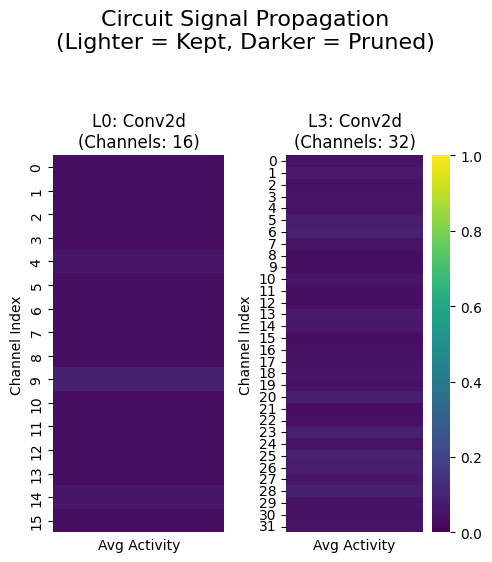


Visualization saved to out/circuit_visualization.png
Saved visualization to: out/circuit_viz_class_0.png
Extracting circuit for class 1
 Processing Class 1 
Configuration: Device=cuda, Lambda=50.0, Dataset=mnist-class-1


/usr/local/lib/python3.12/dist-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/datasets/mnist.py:66: UserWarning: train_labels has been renamed targets
  warnings.warn("train_labels has been renamed targets")
/usr/local/lib/python3.12/dist-packages/torchvision/datasets/mnist.py:71: UserWarning: test_labels has been renamed targets
  warnings.warn("test_labels has been renamed targets")
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 16 worker processes in total. Our suggested max number of worker in current system is 4, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker cr

Calculating mean activations...
Initializing Circuit...
Initializing Optimizer...
Extracting Circuit (L0 Lambda=50.0)...
Epoch 0 | Loss: 11.3715 | Avg Mask: -0.945 | Total Non-Zero: 408.0 | | Circuit Acc: 0.9522
Epoch 1 | Loss: 1.1246 | Avg Mask: -0.953 | Total Non-Zero: 339.0 | | Circuit Acc: 0.9680
Epoch 2 | Loss: 1.0002 | Avg Mask: -0.955 | Total Non-Zero: 325.0 | | Circuit Acc: 1.0000
Epoch 3 | Loss: 0.9535 | Avg Mask: -0.957 | Total Non-Zero: 314.0 | | Circuit Acc: 0.9991
Epoch 4 | Loss: 0.9432 | Avg Mask: -0.957 | Total Non-Zero: 299.0 | | Circuit Acc: 0.9997

--- Visualizing Circuit for Class 1 ---


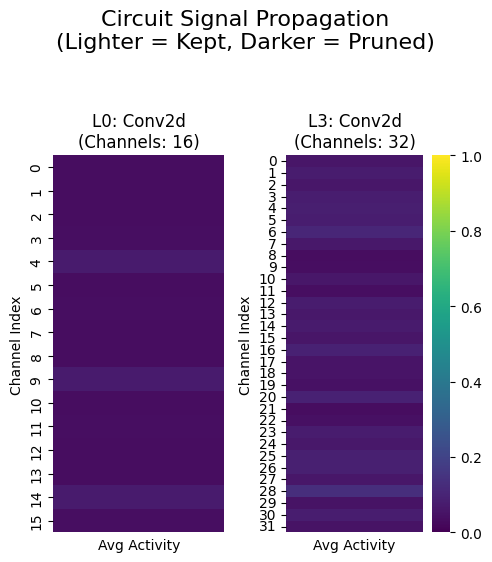


Visualization saved to out/circuit_visualization.png
Saved visualization to: out/circuit_viz_class_1.png
Extracting circuit for class 2
 Processing Class 2 
Configuration: Device=cuda, Lambda=50.0, Dataset=mnist-class-2


/usr/local/lib/python3.12/dist-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/datasets/mnist.py:66: UserWarning: train_labels has been renamed targets
  warnings.warn("train_labels has been renamed targets")
/usr/local/lib/python3.12/dist-packages/torchvision/datasets/mnist.py:71: UserWarning: test_labels has been renamed targets
  warnings.warn("test_labels has been renamed targets")
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 16 worker processes in total. Our suggested max number of worker in current system is 4, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker cr

Calculating mean activations...
Initializing Circuit...
Initializing Optimizer...
Extracting Circuit (L0 Lambda=50.0)...
Epoch 0 | Loss: 12.9291 | Avg Mask: -0.958 | Total Non-Zero: 381.0 | | Circuit Acc: 0.9973
Epoch 1 | Loss: 0.7109 | Avg Mask: -0.976 | Total Non-Zero: 194.0 | | Circuit Acc: 1.0000
Epoch 2 | Loss: 0.5451 | Avg Mask: -0.976 | Total Non-Zero: 166.0 | | Circuit Acc: 1.0000
Epoch 3 | Loss: 0.5215 | Avg Mask: -0.975 | Total Non-Zero: 168.0 | | Circuit Acc: 1.0000
Epoch 4 | Loss: 0.5031 | Avg Mask: -0.976 | Total Non-Zero: 164.0 | | Circuit Acc: 1.0000

--- Visualizing Circuit for Class 2 ---


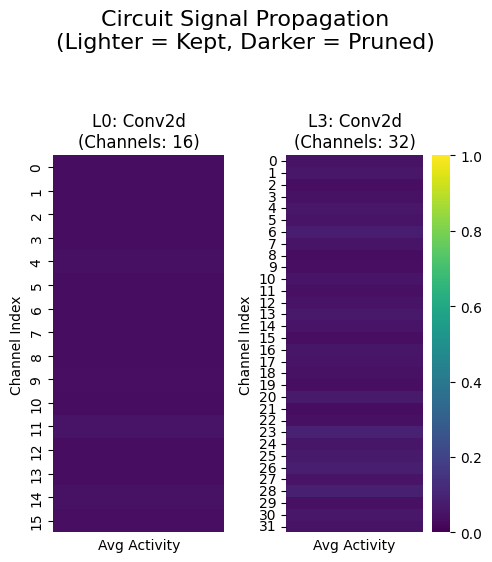


Visualization saved to out/circuit_visualization.png
Saved visualization to: out/circuit_viz_class_2.png
Extracting circuit for class 3
 Processing Class 3 
Configuration: Device=cuda, Lambda=50.0, Dataset=mnist-class-3


/usr/local/lib/python3.12/dist-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/datasets/mnist.py:66: UserWarning: train_labels has been renamed targets
  warnings.warn("train_labels has been renamed targets")
/usr/local/lib/python3.12/dist-packages/torchvision/datasets/mnist.py:71: UserWarning: test_labels has been renamed targets
  warnings.warn("test_labels has been renamed targets")
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 16 worker processes in total. Our suggested max number of worker in current system is 4, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker cr

Calculating mean activations...
Initializing Circuit...
Initializing Optimizer...
Extracting Circuit (L0 Lambda=50.0)...
Epoch 0 | Loss: 12.5541 | Avg Mask: -0.964 | Total Non-Zero: 343.0 | | Circuit Acc: 1.0000
Epoch 1 | Loss: 0.5721 | Avg Mask: -0.983 | Total Non-Zero: 134.0 | | Circuit Acc: 1.0000
Epoch 2 | Loss: 0.3637 | Avg Mask: -0.984 | Total Non-Zero: 105.0 | | Circuit Acc: 1.0000
Epoch 3 | Loss: 0.3469 | Avg Mask: -0.983 | Total Non-Zero: 124.0 | | Circuit Acc: 1.0000
Epoch 4 | Loss: 0.3494 | Avg Mask: -0.983 | Total Non-Zero: 100.0 | | Circuit Acc: 1.0000

--- Visualizing Circuit for Class 3 ---


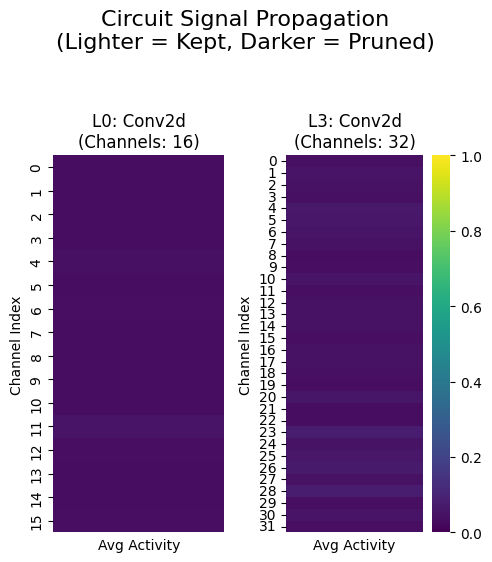


Visualization saved to out/circuit_visualization.png
Saved visualization to: out/circuit_viz_class_3.png
Extracting circuit for class 4
 Processing Class 4 
Configuration: Device=cuda, Lambda=50.0, Dataset=mnist-class-4


/usr/local/lib/python3.12/dist-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/datasets/mnist.py:66: UserWarning: train_labels has been renamed targets
  warnings.warn("train_labels has been renamed targets")
/usr/local/lib/python3.12/dist-packages/torchvision/datasets/mnist.py:71: UserWarning: test_labels has been renamed targets
  warnings.warn("test_labels has been renamed targets")
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 16 worker processes in total. Our suggested max number of worker in current system is 4, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker cr

Calculating mean activations...
Initializing Circuit...
Initializing Optimizer...
Extracting Circuit (L0 Lambda=50.0)...
Epoch 0 | Loss: 13.1018 | Avg Mask: -0.945 | Total Non-Zero: 455.0 | | Circuit Acc: 0.9914
Epoch 1 | Loss: 0.9436 | Avg Mask: -0.969 | Total Non-Zero: 252.0 | | Circuit Acc: 1.0000
Epoch 2 | Loss: 0.6996 | Avg Mask: -0.970 | Total Non-Zero: 233.0 | | Circuit Acc: 1.0000
Epoch 3 | Loss: 0.6608 | Avg Mask: -0.970 | Total Non-Zero: 215.0 | | Circuit Acc: 1.0000
Epoch 4 | Loss: 0.6528 | Avg Mask: -0.970 | Total Non-Zero: 196.0 | | Circuit Acc: 1.0000

--- Visualizing Circuit for Class 4 ---


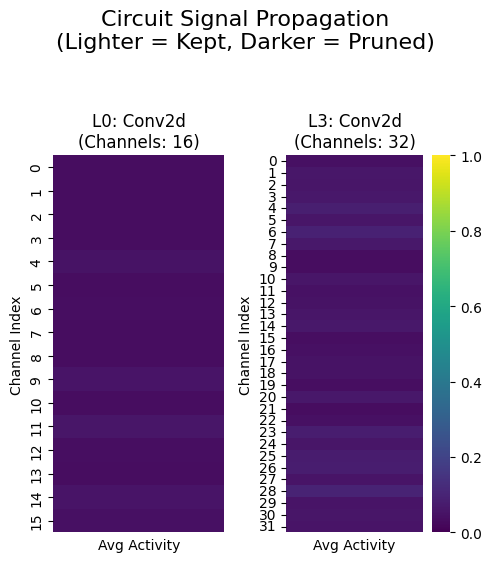


Visualization saved to out/circuit_visualization.png
Saved visualization to: out/circuit_viz_class_4.png
Extracting circuit for class 5
 Processing Class 5 
Configuration: Device=cuda, Lambda=50.0, Dataset=mnist-class-5


/usr/local/lib/python3.12/dist-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/datasets/mnist.py:66: UserWarning: train_labels has been renamed targets
  warnings.warn("train_labels has been renamed targets")
/usr/local/lib/python3.12/dist-packages/torchvision/datasets/mnist.py:71: UserWarning: test_labels has been renamed targets
  warnings.warn("test_labels has been renamed targets")
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 16 worker processes in total. Our suggested max number of worker in current system is 4, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker cr

Calculating mean activations...
Initializing Circuit...
Initializing Optimizer...
Extracting Circuit (L0 Lambda=50.0)...
Epoch 0 | Loss: 14.3060 | Avg Mask: -0.934 | Total Non-Zero: 580.0 | | Circuit Acc: 0.9906
Epoch 1 | Loss: 0.9869 | Avg Mask: -0.973 | Total Non-Zero: 221.0 | | Circuit Acc: 1.0000
Epoch 2 | Loss: 0.5763 | Avg Mask: -0.977 | Total Non-Zero: 167.0 | | Circuit Acc: 1.0000
Epoch 3 | Loss: 0.5140 | Avg Mask: -0.976 | Total Non-Zero: 168.0 | | Circuit Acc: 1.0000
Epoch 4 | Loss: 0.5004 | Avg Mask: -0.976 | Total Non-Zero: 152.0 | | Circuit Acc: 1.0000

--- Visualizing Circuit for Class 5 ---


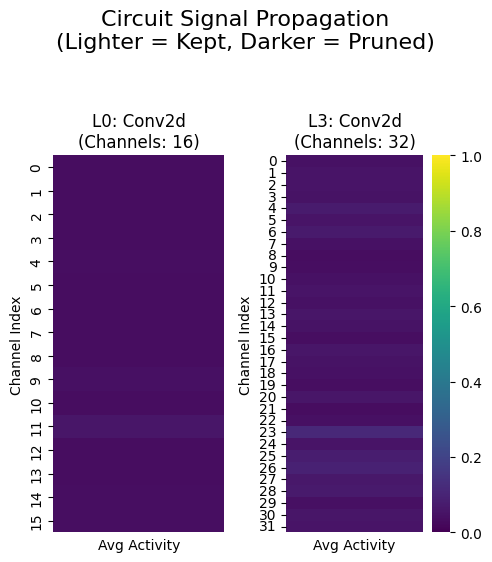


Visualization saved to out/circuit_visualization.png
Saved visualization to: out/circuit_viz_class_5.png
Extracting circuit for class 6
 Processing Class 6 
Configuration: Device=cuda, Lambda=50.0, Dataset=mnist-class-6


/usr/local/lib/python3.12/dist-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/datasets/mnist.py:66: UserWarning: train_labels has been renamed targets
  warnings.warn("train_labels has been renamed targets")
/usr/local/lib/python3.12/dist-packages/torchvision/datasets/mnist.py:71: UserWarning: test_labels has been renamed targets
  warnings.warn("test_labels has been renamed targets")
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 16 worker processes in total. Our suggested max number of worker in current system is 4, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker cr

Calculating mean activations...
Initializing Circuit...
Initializing Optimizer...
Extracting Circuit (L0 Lambda=50.0)...
Epoch 0 | Loss: 12.6757 | Avg Mask: -0.948 | Total Non-Zero: 431.0 | | Circuit Acc: 0.9799
Epoch 1 | Loss: 1.0994 | Avg Mask: -0.961 | Total Non-Zero: 325.0 | | Circuit Acc: 0.9888
Epoch 2 | Loss: 0.9375 | Avg Mask: -0.963 | Total Non-Zero: 295.0 | | Circuit Acc: 0.9865
Epoch 3 | Loss: 0.8879 | Avg Mask: -0.963 | Total Non-Zero: 300.0 | | Circuit Acc: 0.9878
Epoch 4 | Loss: 0.8634 | Avg Mask: -0.963 | Total Non-Zero: 280.0 | | Circuit Acc: 0.9958

--- Visualizing Circuit for Class 6 ---


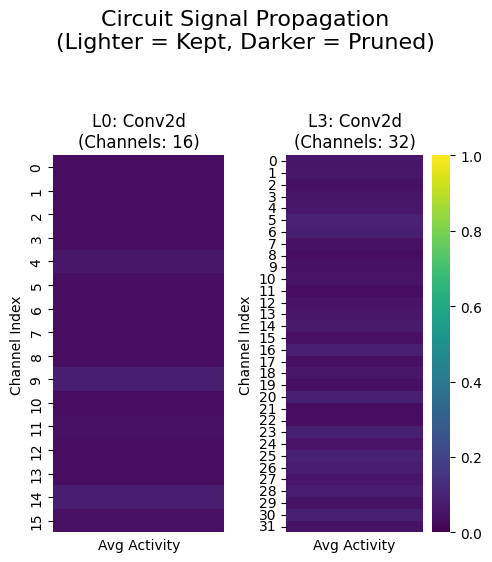


Visualization saved to out/circuit_visualization.png
Saved visualization to: out/circuit_viz_class_6.png
Extracting circuit for class 7
 Processing Class 7 
Configuration: Device=cuda, Lambda=50.0, Dataset=mnist-class-7


/usr/local/lib/python3.12/dist-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/datasets/mnist.py:66: UserWarning: train_labels has been renamed targets
  warnings.warn("train_labels has been renamed targets")
/usr/local/lib/python3.12/dist-packages/torchvision/datasets/mnist.py:71: UserWarning: test_labels has been renamed targets
  warnings.warn("test_labels has been renamed targets")
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 16 worker processes in total. Our suggested max number of worker in current system is 4, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker cr

Calculating mean activations...
Initializing Circuit...
Initializing Optimizer...
Extracting Circuit (L0 Lambda=50.0)...
Epoch 0 | Loss: 12.5967 | Avg Mask: -0.943 | Total Non-Zero: 497.0 | | Circuit Acc: 0.9810
Epoch 1 | Loss: 1.1847 | Avg Mask: -0.957 | Total Non-Zero: 354.0 | | Circuit Acc: 0.9777
Epoch 2 | Loss: 1.0474 | Avg Mask: -0.957 | Total Non-Zero: 314.0 | | Circuit Acc: 0.9893
Epoch 3 | Loss: 1.0179 | Avg Mask: -0.957 | Total Non-Zero: 343.0 | | Circuit Acc: 0.9939
Epoch 4 | Loss: 0.9939 | Avg Mask: -0.957 | Total Non-Zero: 335.0 | | Circuit Acc: 0.9997

--- Visualizing Circuit for Class 7 ---


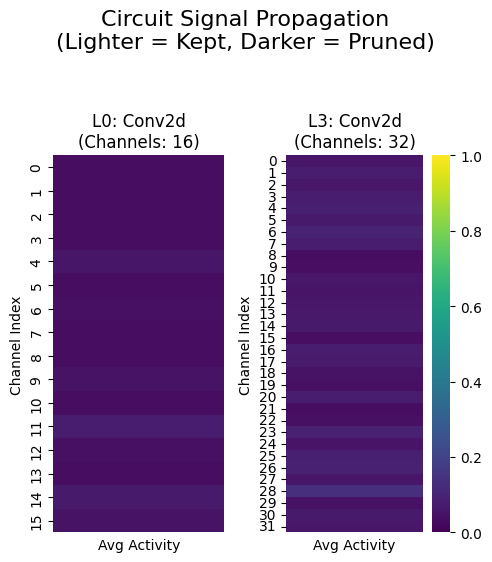


Visualization saved to out/circuit_visualization.png
Saved visualization to: out/circuit_viz_class_7.png
Extracting circuit for class 8
 Processing Class 8 
Configuration: Device=cuda, Lambda=50.0, Dataset=mnist-class-8


/usr/local/lib/python3.12/dist-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/datasets/mnist.py:66: UserWarning: train_labels has been renamed targets
  warnings.warn("train_labels has been renamed targets")
/usr/local/lib/python3.12/dist-packages/torchvision/datasets/mnist.py:71: UserWarning: test_labels has been renamed targets
  warnings.warn("test_labels has been renamed targets")
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 16 worker processes in total. Our suggested max number of worker in current system is 4, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker cr

Calculating mean activations...


Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7ad18f33a660>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1654, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1637, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7ad18f33a660>Exception ignored in: Exception ignored in: 
<function _MultiProcessingDataLoaderIter.__del__ at 0x7ad18f33a660>Traceback (most recent call last):
<function _MultiProcessingDataLoaderIter.__del__ at 0x7ad18f33a660>
  File "/usr/local/lib/python3.12/dist-pa

Initializing Circuit...
Initializing Optimizer...
Extracting Circuit (L0 Lambda=50.0)...


Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7ad18f33a660>Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7ad18f33a660>
Traceback (most recent call last):

Traceback (most recent call last):
Exception ignored in: Exception ignored in:   File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1654, in __del__
<function _MultiProcessingDataLoaderIter.__del__ at 0x7ad18f33a660>  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1654, in __del__
Exception ignored in:     <function _MultiProcessingDataLoaderIter.__del__ at 0x7ad18f33a660>self._shutdown_workers()

    Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7ad18f33a660>

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7ad18f33a660>Traceback (most recent call last):
self._shutdown_workers()<function _MultiProcessingDataLoaderIter.__del__ at 0x7ad18f33a660>
Tra

Epoch 0 | Loss: 12.9267 | Avg Mask: -0.964 | Total Non-Zero: 345.0 | | Circuit Acc: 1.0000
Epoch 1 | Loss: 0.5490 | Avg Mask: -0.987 | Total Non-Zero: 111.0 | | Circuit Acc: 1.0000
Epoch 2 | Loss: 0.2828 | Avg Mask: -0.989 | Total Non-Zero: 83.0 | | Circuit Acc: 1.0000
Epoch 3 | Loss: 0.2514 | Avg Mask: -0.988 | Total Non-Zero: 67.0 | | Circuit Acc: 1.0000
Epoch 4 | Loss: 0.2508 | Avg Mask: -0.988 | Total Non-Zero: 77.0 | | Circuit Acc: 1.0000

--- Visualizing Circuit for Class 8 ---


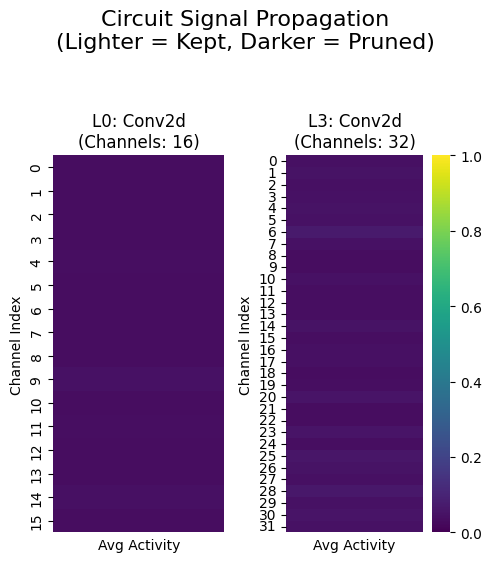


Visualization saved to out/circuit_visualization.png
Saved visualization to: out/circuit_viz_class_8.png
Extracting circuit for class 9
 Processing Class 9 
Configuration: Device=cuda, Lambda=50.0, Dataset=mnist-class-9


/usr/local/lib/python3.12/dist-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/datasets/mnist.py:66: UserWarning: train_labels has been renamed targets
  warnings.warn("train_labels has been renamed targets")
/usr/local/lib/python3.12/dist-packages/torchvision/datasets/mnist.py:71: UserWarning: test_labels has been renamed targets
  warnings.warn("test_labels has been renamed targets")
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 16 worker processes in total. Our suggested max number of worker in current system is 4, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker cr

Calculating mean activations...
Initializing Circuit...
Initializing Optimizer...
Extracting Circuit (L0 Lambda=50.0)...
Epoch 0 | Loss: 12.8216 | Avg Mask: -0.960 | Total Non-Zero: 360.0 | | Circuit Acc: 0.9970
Epoch 1 | Loss: 0.7190 | Avg Mask: -0.976 | Total Non-Zero: 194.0 | | Circuit Acc: 1.0000
Epoch 2 | Loss: 0.5282 | Avg Mask: -0.976 | Total Non-Zero: 179.0 | | Circuit Acc: 1.0000
Epoch 3 | Loss: 0.5109 | Avg Mask: -0.975 | Total Non-Zero: 181.0 | | Circuit Acc: 1.0000
Epoch 4 | Loss: 0.4971 | Avg Mask: -0.975 | Total Non-Zero: 162.0 | | Circuit Acc: 1.0000

--- Visualizing Circuit for Class 9 ---


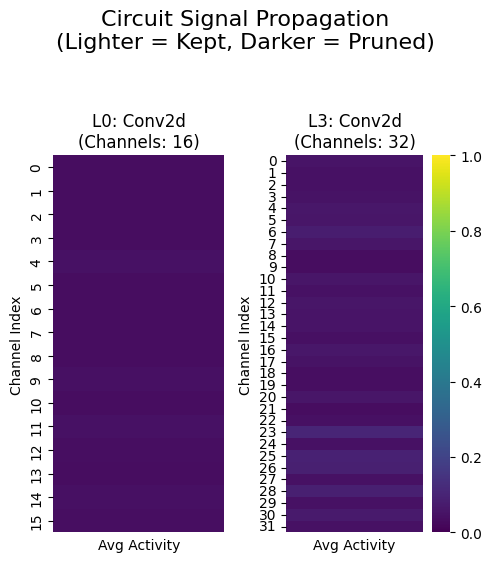


Visualization saved to out/circuit_visualization.png
Saved visualization to: out/circuit_viz_class_9.png


In [84]:
dict_10_classes = get_circuit_from_classes(
    model=model, 
    epochs=5,
    lr=0.1,
    l0_lambda=5e+1,
    seed=seed_list[1]
)

In [85]:
# MODEL_NAME =  "model"
# .save(model)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 16 worker processes in total. Our suggested max number of worker in current system is 4, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


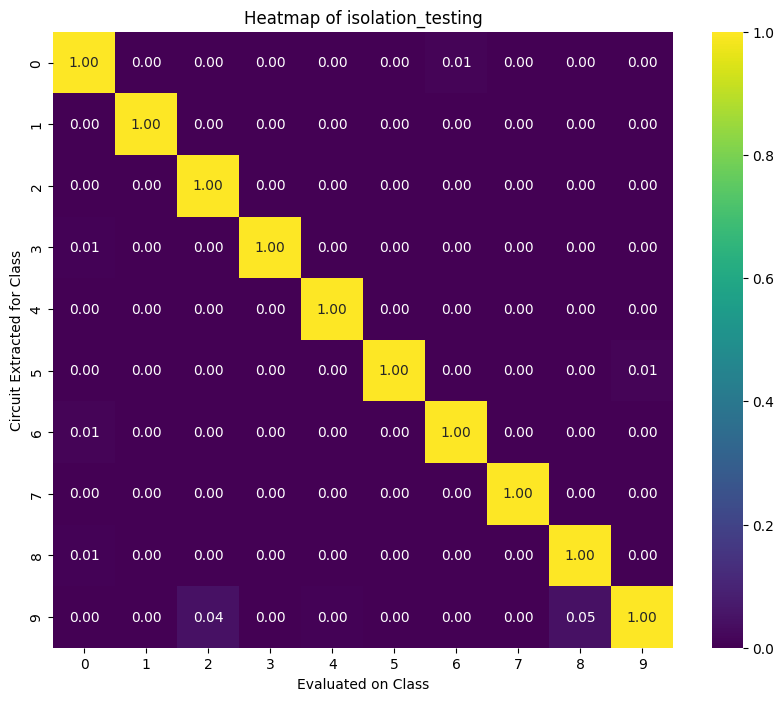

In [86]:
iso_heatmap = plot_circuit_testing_heatmap(
    circuits_dict=dict_10_classes,
    test_func=isolation_testing,
    dataloader=testloader,
    dev=device
)
plt.show()

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 16 worker processes in total. Our suggested max number of worker in current system is 4, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


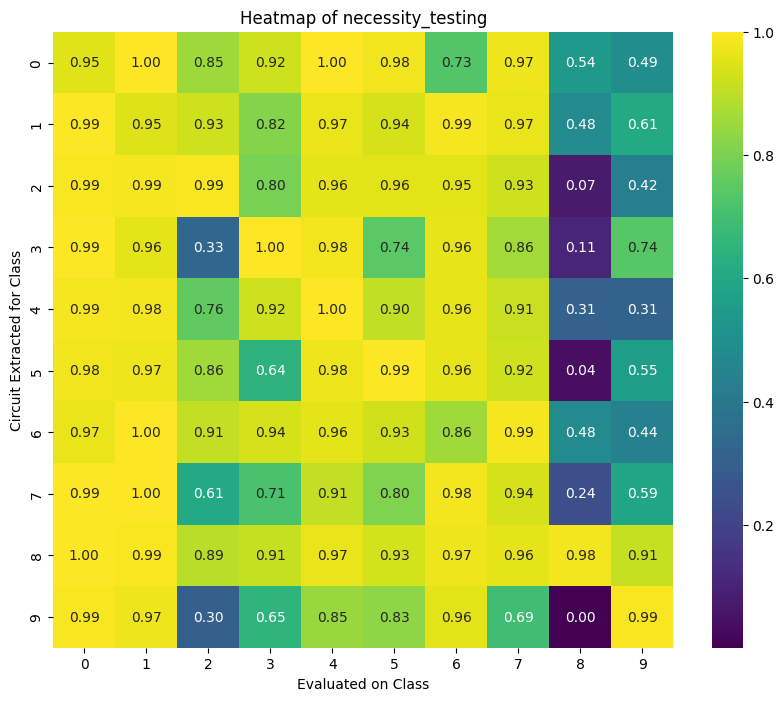

In [87]:
nec_heatmap = plot_circuit_testing_heatmap(
    circuits_dict=dict_10_classes,
    test_func=necessity_testing,
    dataloader=testloader,
    dev=device
)
# plt.savefig("out/nec_map.png", bbox_inches='tight')
plt.show()

In [88]:
# for k,v in dict_10_classes.items():
#     invert_masks(v)

In [89]:
# dict_10_classes

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 16 worker processes in total. Our suggested max number of worker in current system is 4, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


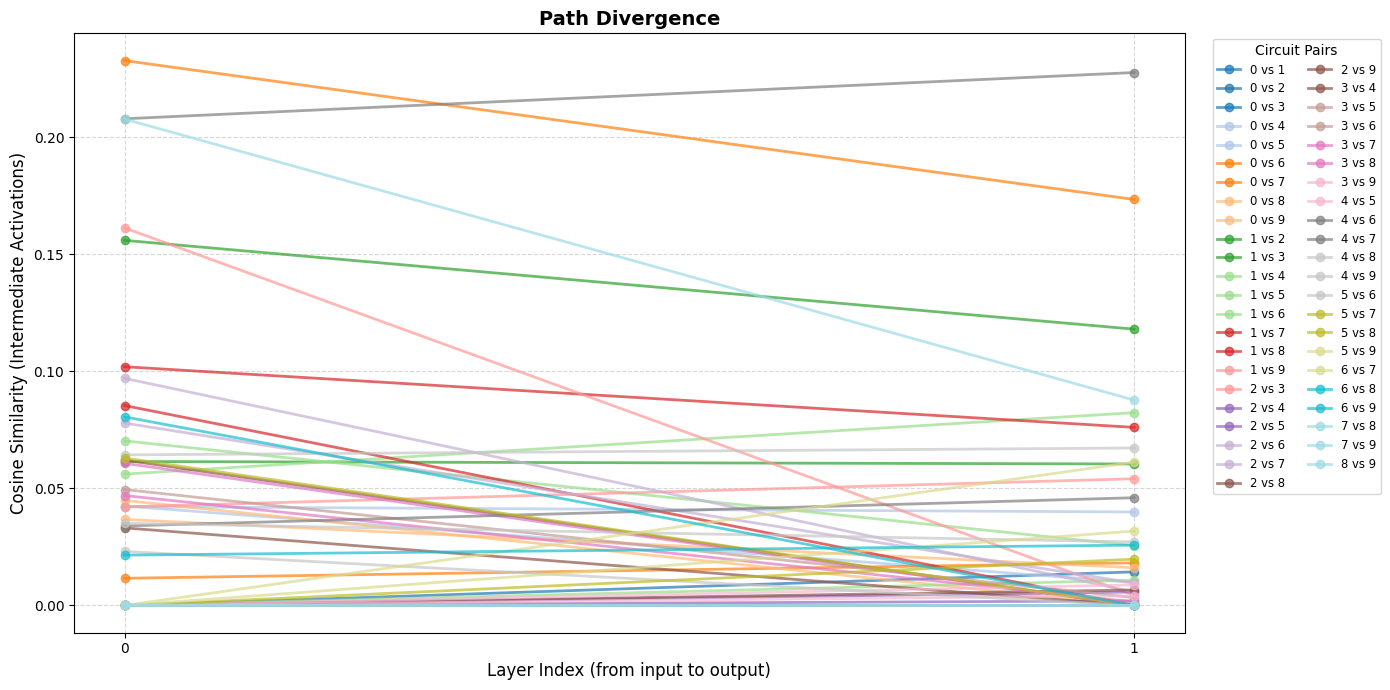

In [90]:
divergence_results = path_divergence_dict(
    circuits_dict=dict_10_classes,
    loader=trainloader,
    device=device
)

plot_path_divergence_trajectories(divergence_results, 'out/path_div_trajectory.png', title='Path Divergence')

In [91]:
sorted_pairs = sorted(divergence_results.items(), key=lambda x: x[1][-1], reverse=True)
    
for (c_a, c_b), layer_sims in sorted_pairs[:5]:
    formatted_sims = " | ".join([f"L{i}: {s:.3f}" for i, s in enumerate(layer_sims)])
    print(f"Classes ({c_a} vs {c_b}): {formatted_sims}")

Classes (4 vs 7): L0: 0.208 | L1: 0.228
Classes (0 vs 6): L0: 0.233 | L1: 0.173
Classes (1 vs 2): L0: 0.156 | L1: 0.118
Classes (7 vs 9): L0: 0.208 | L1: 0.088
Classes (1 vs 6): L0: 0.056 | L1: 0.082


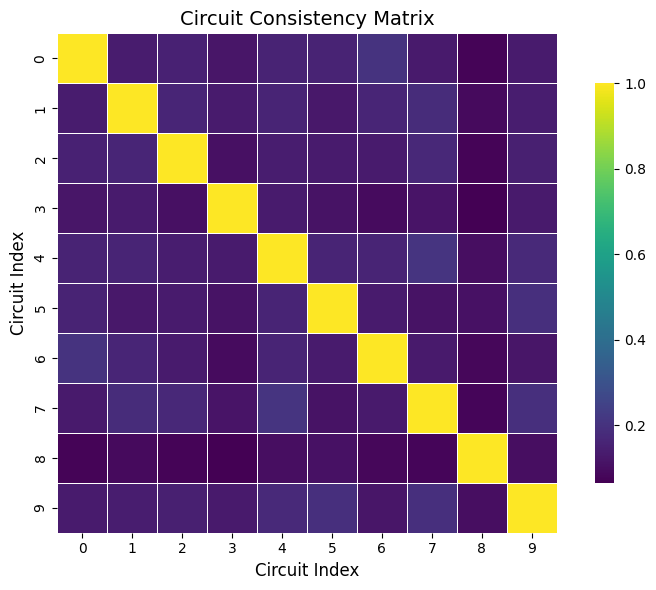

In [92]:
distinct_consistency_matrix = circuit_consistency_matrix(list(dict_10_classes.values()), len(dict_10_classes))

visualize_consistency_matrix(distinct_consistency_matrix)

In [95]:
for target_class in [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]:
    print(f"\nDeconstructing Circuit for Class {target_class}:")
    layerwise_circuits = get_layerwise_circuits(dict_10_classes[target_class])
    
    layer_accs = []
    for layer_idx, l_circ in layerwise_circuits.items():
        acc_dict = class_wise_acc(l_circ, testloader, classes=[target_class], device=device)
        acc = acc_dict[target_class]
        layer_accs.append(acc)
        print(f"Layer {layer_idx} Isolation Acc: {acc:.2%}")
        
    plt.figure(figsize=(8, 4))
    plt.plot(list(layerwise_circuits.keys()), layer_accs, marker='o')
    plt.title(f"Class {target_class}: Accuracy when ONLY Layer X is Pruned")
    plt.xlabel("Layer Index")
    plt.ylabel("Accuracy")
    plt.savefig(f"out/layerwise_class_{target_class}.png")
    plt.close()


Deconstructing Circuit for Class 0:


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 16 worker processes in total. Our suggested max number of worker in current system is 4, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


Layer 0 Isolation Acc: 100.00%
Layer 3 Isolation Acc: 58.57%

Deconstructing Circuit for Class 1:
Layer 0 Isolation Acc: 98.59%
Layer 3 Isolation Acc: 81.94%

Deconstructing Circuit for Class 2:
Layer 0 Isolation Acc: 81.49%
Layer 3 Isolation Acc: 4.26%

Deconstructing Circuit for Class 3:
Layer 0 Isolation Acc: 94.65%
Layer 3 Isolation Acc: 30.00%

Deconstructing Circuit for Class 4:
Layer 0 Isolation Acc: 96.44%
Layer 3 Isolation Acc: 65.17%

Deconstructing Circuit for Class 5:
Layer 0 Isolation Acc: 71.41%
Layer 3 Isolation Acc: 13.79%

Deconstructing Circuit for Class 6:
Layer 0 Isolation Acc: 92.48%
Layer 3 Isolation Acc: 75.57%

Deconstructing Circuit for Class 7:
Layer 0 Isolation Acc: 97.37%
Layer 3 Isolation Acc: 71.01%

Deconstructing Circuit for Class 8:
Layer 0 Isolation Acc: 100.00%
Layer 3 Isolation Acc: 29.67%

Deconstructing Circuit for Class 9:
Layer 0 Isolation Acc: 98.22%
Layer 3 Isolation Acc: 7.83%



Interpolating between Class 4 and Class 7...
Alpha 0.0: Acc Class 4 = 0.00%, Acc Class 7 = 99.90%
Alpha 0.1: Acc Class 4 = 43.89%, Acc Class 7 = 95.23%
Alpha 0.2: Acc Class 4 = 44.91%, Acc Class 7 = 95.04%
Alpha 0.3: Acc Class 4 = 45.42%, Acc Class 7 = 95.04%
Alpha 0.4: Acc Class 4 = 46.03%, Acc Class 7 = 95.04%
Alpha 0.6: Acc Class 4 = 100.00%, Acc Class 7 = 0.00%
Alpha 0.7: Acc Class 4 = 100.00%, Acc Class 7 = 0.00%
Alpha 0.8: Acc Class 4 = 100.00%, Acc Class 7 = 0.00%
Alpha 0.9: Acc Class 4 = 100.00%, Acc Class 7 = 0.00%
Alpha 1.0: Acc Class 4 = 100.00%, Acc Class 7 = 0.00%


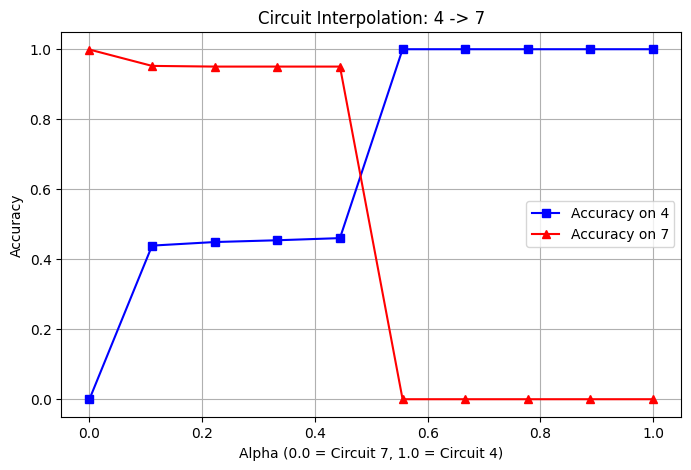


Interpolating between Class 0 and Class 6...
Alpha 0.0: Acc Class 0 = 0.00%, Acc Class 6 = 99.37%
Alpha 0.1: Acc Class 0 = 0.61%, Acc Class 6 = 97.18%
Alpha 0.2: Acc Class 0 = 0.41%, Acc Class 6 = 96.87%
Alpha 0.3: Acc Class 0 = 0.31%, Acc Class 6 = 96.76%
Alpha 0.4: Acc Class 0 = 0.31%, Acc Class 6 = 96.24%
Alpha 0.6: Acc Class 0 = 98.78%, Acc Class 6 = 0.00%
Alpha 0.7: Acc Class 0 = 98.78%, Acc Class 6 = 0.00%
Alpha 0.8: Acc Class 0 = 98.88%, Acc Class 6 = 0.00%
Alpha 0.9: Acc Class 0 = 98.78%, Acc Class 6 = 0.00%
Alpha 1.0: Acc Class 0 = 100.00%, Acc Class 6 = 0.00%


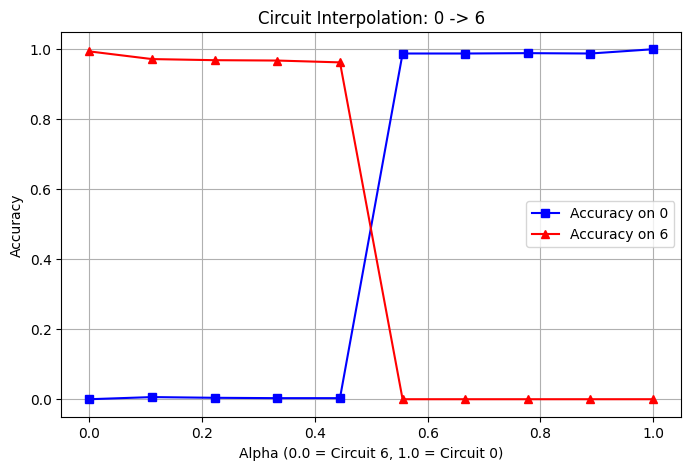


Interpolating between Class 1 and Class 2...
Alpha 0.0: Acc Class 1 = 0.00%, Acc Class 2 = 100.00%
Alpha 0.1: Acc Class 1 = 0.00%, Acc Class 2 = 100.00%
Alpha 0.2: Acc Class 1 = 0.00%, Acc Class 2 = 100.00%
Alpha 0.3: Acc Class 1 = 0.00%, Acc Class 2 = 100.00%
Alpha 0.4: Acc Class 1 = 0.00%, Acc Class 2 = 100.00%
Alpha 0.6: Acc Class 1 = 90.13%, Acc Class 2 = 68.80%
Alpha 0.7: Acc Class 1 = 90.66%, Acc Class 2 = 68.41%
Alpha 0.8: Acc Class 1 = 90.66%, Acc Class 2 = 68.41%
Alpha 0.9: Acc Class 1 = 90.66%, Acc Class 2 = 68.41%
Alpha 1.0: Acc Class 1 = 100.00%, Acc Class 2 = 7.95%


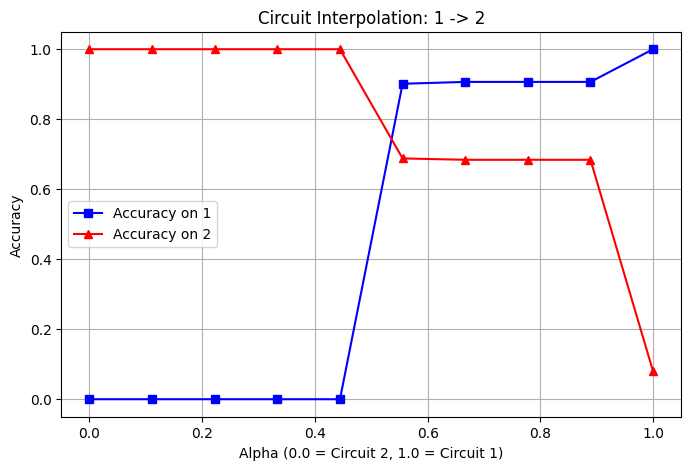


Interpolating between Class 7 and Class 9...
Alpha 0.0: Acc Class 7 = 0.00%, Acc Class 9 = 100.00%
Alpha 0.1: Acc Class 7 = 0.00%, Acc Class 9 = 100.00%
Alpha 0.2: Acc Class 7 = 0.00%, Acc Class 9 = 100.00%
Alpha 0.3: Acc Class 7 = 0.00%, Acc Class 9 = 100.00%
Alpha 0.4: Acc Class 7 = 0.00%, Acc Class 9 = 100.00%
Alpha 0.6: Acc Class 7 = 87.84%, Acc Class 9 = 33.60%
Alpha 0.7: Acc Class 7 = 89.11%, Acc Class 9 = 27.95%
Alpha 0.8: Acc Class 7 = 89.30%, Acc Class 9 = 27.45%
Alpha 0.9: Acc Class 7 = 89.59%, Acc Class 9 = 27.06%
Alpha 1.0: Acc Class 7 = 99.90%, Acc Class 9 = 0.00%


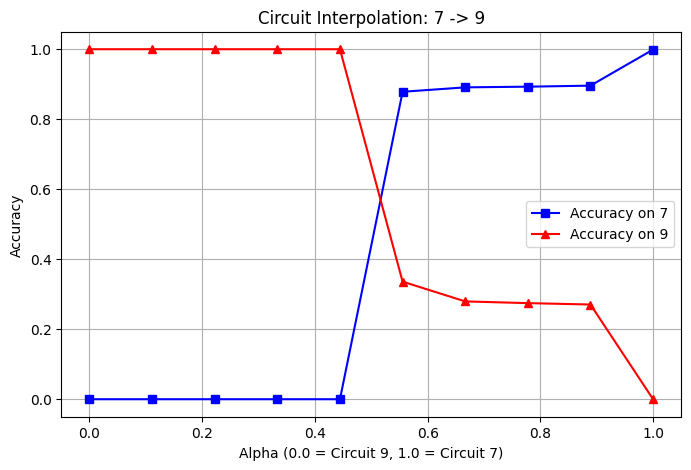


Interpolating between Class 1 and Class 6...
Alpha 0.0: Acc Class 1 = 0.00%, Acc Class 6 = 99.37%
Alpha 0.1: Acc Class 1 = 0.00%, Acc Class 6 = 99.48%
Alpha 0.2: Acc Class 1 = 0.00%, Acc Class 6 = 99.58%
Alpha 0.3: Acc Class 1 = 0.00%, Acc Class 6 = 99.58%
Alpha 0.4: Acc Class 1 = 0.00%, Acc Class 6 = 99.16%
Alpha 0.6: Acc Class 1 = 97.97%, Acc Class 6 = 0.00%
Alpha 0.7: Acc Class 1 = 97.44%, Acc Class 6 = 0.00%
Alpha 0.8: Acc Class 1 = 97.00%, Acc Class 6 = 0.00%
Alpha 0.9: Acc Class 1 = 96.83%, Acc Class 6 = 0.00%
Alpha 1.0: Acc Class 1 = 100.00%, Acc Class 6 = 0.00%


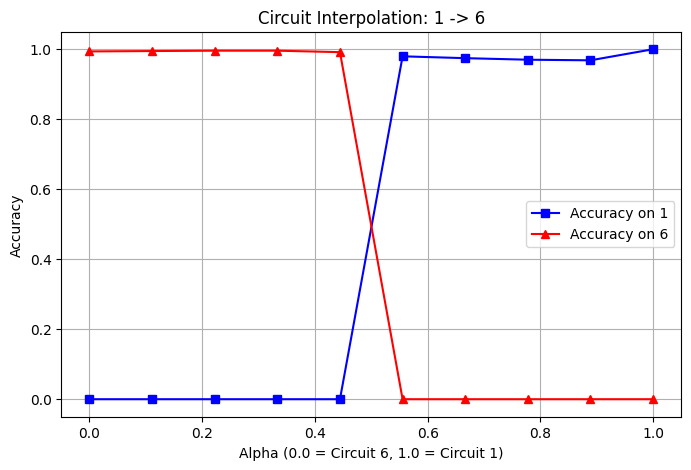

In [96]:
pairs_to_interpolate = [s[0] for s in sorted_pairs[:5]] #[(3, 8), (4, 9), (1, 7), (6, 9), (0, 6), (1,4), (4, 6), (1, 2)]

for (class_a, class_b) in pairs_to_interpolate:
    print(f"\nInterpolating between Class {class_a} and Class {class_b}...")
    interp_circuits = get_interpolated_circuits(
        c_a=dict_10_classes[class_a], 
        c_b=dict_10_classes[class_b], 
        steps=10
    )
    
    acc_a_list, acc_b_list = [], []
    alphas = list(interp_circuits.keys())
    
    for alpha, interp_c in interp_circuits.items():
        accs = class_wise_acc(interp_c, testloader, classes=[class_a, class_b], device=device)
        acc_a_list.append(accs[class_a])
        acc_b_list.append(accs[class_b])
        print(f"Alpha {alpha:.1f}: Acc Class {class_a} = {accs[class_a]:.2%}, Acc Class {class_b} = {accs[class_b]:.2%}")
        
    plt.figure(figsize=(8, 5))
    plt.plot(alphas, acc_a_list, marker='s', label=f'Accuracy on {class_a}', color='blue')
    plt.plot(alphas, acc_b_list, marker='^', label=f'Accuracy on {class_b}', color='red')
    plt.title(f"Circuit Interpolation: {class_a} -> {class_b}")
    plt.xlabel(f"Alpha (0.0 = Circuit {class_b}, 1.0 = Circuit {class_a})")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()
    # plt.savefig(f"out/interpolation_{class_a}_to_{class_b}.png")
    # plt.close()

### get n circuits same class same model

Extracting duplicate 1/10 for class 8
 Processing Class 8 
Configuration: Device=cuda, Lambda=50.0, Dataset=mnist-class-8


/usr/local/lib/python3.12/dist-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/datasets/mnist.py:66: UserWarning: train_labels has been renamed targets
  warnings.warn("train_labels has been renamed targets")
/usr/local/lib/python3.12/dist-packages/torchvision/datasets/mnist.py:71: UserWarning: test_labels has been renamed targets
  warnings.warn("test_labels has been renamed targets")


Calculating mean activations...
Initializing Circuit...
Initializing Optimizer...
Extracting Circuit (L0 Lambda=50.0)...
Epoch 0 | Loss: 12.9239 | Avg Mask: -0.967 | Total Non-Zero: 310.0 | | Circuit Acc: 1.0000
Epoch 1 | Loss: 0.5089 | Avg Mask: -0.988 | Total Non-Zero: 110.0 | | Circuit Acc: 1.0000
Epoch 2 | Loss: 0.2771 | Avg Mask: -0.989 | Total Non-Zero: 64.0 | | Circuit Acc: 1.0000
Epoch 3 | Loss: 0.2471 | Avg Mask: -0.988 | Total Non-Zero: 73.0 | | Circuit Acc: 1.0000
Epoch 4 | Loss: 0.2407 | Avg Mask: -0.988 | Total Non-Zero: 64.0 | | Circuit Acc: 1.0000

--- Visualizing Circuit for Class 8 ---


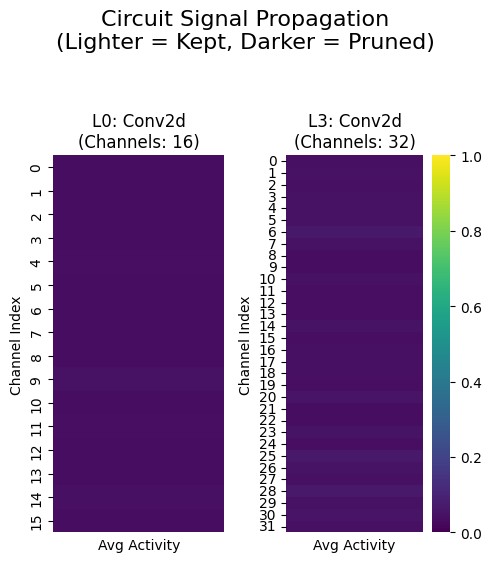


Visualization saved to out/circuit_visualization.png
Saved visualization to: out/circuit_viz_class_8.png
Extracting duplicate 2/10 for class 8
 Processing Class 8 
Configuration: Device=cuda, Lambda=50.0, Dataset=mnist-class-8


/usr/local/lib/python3.12/dist-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/datasets/mnist.py:66: UserWarning: train_labels has been renamed targets
  warnings.warn("train_labels has been renamed targets")
/usr/local/lib/python3.12/dist-packages/torchvision/datasets/mnist.py:71: UserWarning: test_labels has been renamed targets
  warnings.warn("test_labels has been renamed targets")
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 16 worker processes in total. Our suggested max number of worker in current system is 4, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker cr

Calculating mean activations...
Initializing Circuit...
Initializing Optimizer...
Extracting Circuit (L0 Lambda=50.0)...
Epoch 0 | Loss: 12.9792 | Avg Mask: -0.964 | Total Non-Zero: 345.0 | | Circuit Acc: 1.0000
Epoch 1 | Loss: 0.5336 | Avg Mask: -0.987 | Total Non-Zero: 112.0 | | Circuit Acc: 1.0000
Epoch 2 | Loss: 0.2905 | Avg Mask: -0.989 | Total Non-Zero: 73.0 | | Circuit Acc: 1.0000
Epoch 3 | Loss: 0.2471 | Avg Mask: -0.988 | Total Non-Zero: 70.0 | | Circuit Acc: 1.0000
Epoch 4 | Loss: 0.2359 | Avg Mask: -0.988 | Total Non-Zero: 68.0 | | Circuit Acc: 1.0000

--- Visualizing Circuit for Class 8 ---


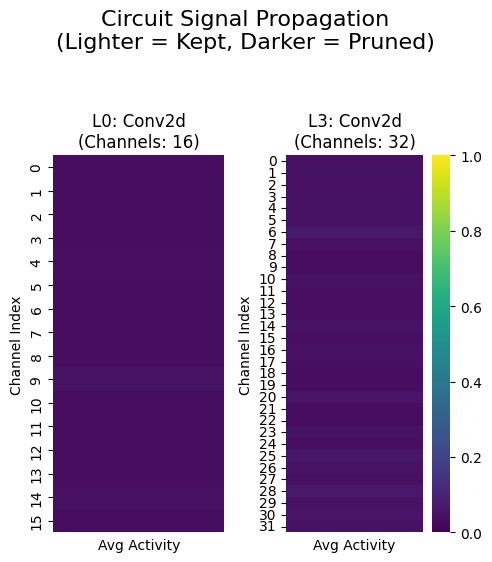


Visualization saved to out/circuit_visualization.png
Saved visualization to: out/circuit_viz_class_8.png
Extracting duplicate 3/10 for class 8
 Processing Class 8 
Configuration: Device=cuda, Lambda=50.0, Dataset=mnist-class-8


/usr/local/lib/python3.12/dist-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/datasets/mnist.py:66: UserWarning: train_labels has been renamed targets
  warnings.warn("train_labels has been renamed targets")
/usr/local/lib/python3.12/dist-packages/torchvision/datasets/mnist.py:71: UserWarning: test_labels has been renamed targets
  warnings.warn("test_labels has been renamed targets")
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 16 worker processes in total. Our suggested max number of worker in current system is 4, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker cr

Calculating mean activations...
Initializing Circuit...
Initializing Optimizer...
Extracting Circuit (L0 Lambda=50.0)...
Epoch 0 | Loss: 12.9225 | Avg Mask: -0.967 | Total Non-Zero: 310.0 | | Circuit Acc: 0.9971
Epoch 1 | Loss: 0.4844 | Avg Mask: -0.988 | Total Non-Zero: 99.0 | | Circuit Acc: 1.0000
Epoch 2 | Loss: 0.2693 | Avg Mask: -0.989 | Total Non-Zero: 79.0 | | Circuit Acc: 1.0000
Epoch 3 | Loss: 0.2457 | Avg Mask: -0.988 | Total Non-Zero: 66.0 | | Circuit Acc: 1.0000
Epoch 4 | Loss: 0.2444 | Avg Mask: -0.988 | Total Non-Zero: 75.0 | | Circuit Acc: 1.0000

--- Visualizing Circuit for Class 8 ---


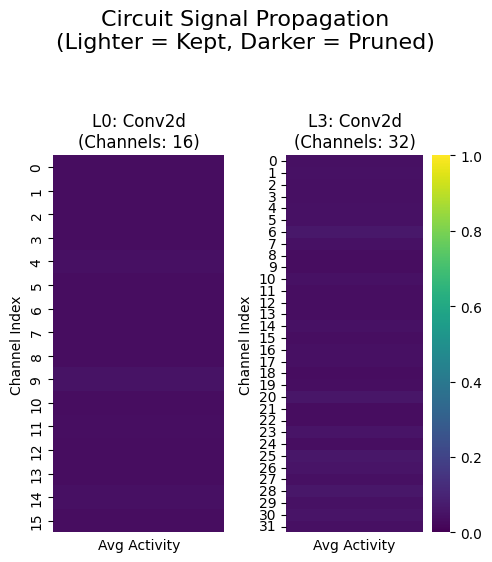


Visualization saved to out/circuit_visualization.png
Saved visualization to: out/circuit_viz_class_8.png
Extracting duplicate 4/10 for class 8
 Processing Class 8 
Configuration: Device=cuda, Lambda=50.0, Dataset=mnist-class-8


/usr/local/lib/python3.12/dist-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/datasets/mnist.py:66: UserWarning: train_labels has been renamed targets
  warnings.warn("train_labels has been renamed targets")
/usr/local/lib/python3.12/dist-packages/torchvision/datasets/mnist.py:71: UserWarning: test_labels has been renamed targets
  warnings.warn("test_labels has been renamed targets")
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 16 worker processes in total. Our suggested max number of worker in current system is 4, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker cr

Calculating mean activations...
Initializing Circuit...
Initializing Optimizer...
Extracting Circuit (L0 Lambda=50.0)...
Epoch 0 | Loss: 12.9456 | Avg Mask: -0.962 | Total Non-Zero: 361.0 | | Circuit Acc: 1.0000
Epoch 1 | Loss: 0.5722 | Avg Mask: -0.987 | Total Non-Zero: 132.0 | | Circuit Acc: 1.0000
Epoch 2 | Loss: 0.3094 | Avg Mask: -0.989 | Total Non-Zero: 79.0 | | Circuit Acc: 1.0000
Epoch 3 | Loss: 0.2596 | Avg Mask: -0.988 | Total Non-Zero: 85.0 | | Circuit Acc: 1.0000
Epoch 4 | Loss: 0.2519 | Avg Mask: -0.988 | Total Non-Zero: 65.0 | | Circuit Acc: 1.0000

--- Visualizing Circuit for Class 8 ---


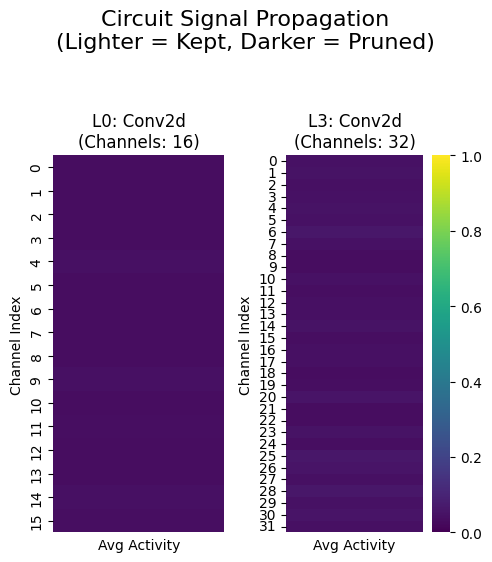


Visualization saved to out/circuit_visualization.png
Saved visualization to: out/circuit_viz_class_8.png
Extracting duplicate 5/10 for class 8
 Processing Class 8 
Configuration: Device=cuda, Lambda=50.0, Dataset=mnist-class-8


/usr/local/lib/python3.12/dist-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/datasets/mnist.py:66: UserWarning: train_labels has been renamed targets
  warnings.warn("train_labels has been renamed targets")
/usr/local/lib/python3.12/dist-packages/torchvision/datasets/mnist.py:71: UserWarning: test_labels has been renamed targets
  warnings.warn("test_labels has been renamed targets")
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 16 worker processes in total. Our suggested max number of worker in current system is 4, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker cr

Calculating mean activations...
Initializing Circuit...
Initializing Optimizer...
Extracting Circuit (L0 Lambda=50.0)...
Epoch 0 | Loss: 12.7596 | Avg Mask: -0.971 | Total Non-Zero: 272.0 | | Circuit Acc: 1.0000
Epoch 1 | Loss: 0.4288 | Avg Mask: -0.989 | Total Non-Zero: 96.0 | | Circuit Acc: 1.0000
Epoch 2 | Loss: 0.2694 | Avg Mask: -0.989 | Total Non-Zero: 68.0 | | Circuit Acc: 1.0000
Epoch 3 | Loss: 0.2416 | Avg Mask: -0.988 | Total Non-Zero: 85.0 | | Circuit Acc: 1.0000
Epoch 4 | Loss: 0.2431 | Avg Mask: -0.988 | Total Non-Zero: 75.0 | | Circuit Acc: 1.0000

--- Visualizing Circuit for Class 8 ---


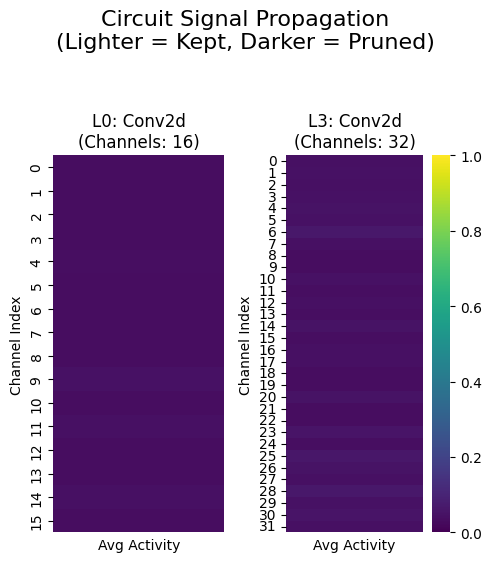


Visualization saved to out/circuit_visualization.png
Saved visualization to: out/circuit_viz_class_8.png
Extracting duplicate 6/10 for class 8
 Processing Class 8 
Configuration: Device=cuda, Lambda=50.0, Dataset=mnist-class-8


/usr/local/lib/python3.12/dist-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/datasets/mnist.py:66: UserWarning: train_labels has been renamed targets
  warnings.warn("train_labels has been renamed targets")
/usr/local/lib/python3.12/dist-packages/torchvision/datasets/mnist.py:71: UserWarning: test_labels has been renamed targets
  warnings.warn("test_labels has been renamed targets")
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 16 worker processes in total. Our suggested max number of worker in current system is 4, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker cr

Calculating mean activations...
Initializing Circuit...
Initializing Optimizer...
Extracting Circuit (L0 Lambda=50.0)...
Epoch 0 | Loss: 12.8863 | Avg Mask: -0.967 | Total Non-Zero: 315.0 | | Circuit Acc: 0.9993
Epoch 1 | Loss: 0.4802 | Avg Mask: -0.988 | Total Non-Zero: 99.0 | | Circuit Acc: 1.0000
Epoch 2 | Loss: 0.2725 | Avg Mask: -0.989 | Total Non-Zero: 75.0 | | Circuit Acc: 1.0000
Epoch 3 | Loss: 0.2504 | Avg Mask: -0.988 | Total Non-Zero: 69.0 | | Circuit Acc: 1.0000
Epoch 4 | Loss: 0.2496 | Avg Mask: -0.988 | Total Non-Zero: 78.0 | | Circuit Acc: 1.0000

--- Visualizing Circuit for Class 8 ---


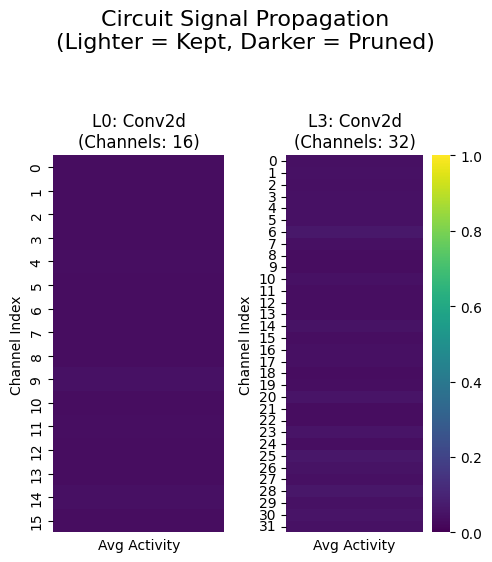


Visualization saved to out/circuit_visualization.png
Saved visualization to: out/circuit_viz_class_8.png
Extracting duplicate 7/10 for class 8
 Processing Class 8 
Configuration: Device=cuda, Lambda=50.0, Dataset=mnist-class-8


/usr/local/lib/python3.12/dist-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/datasets/mnist.py:66: UserWarning: train_labels has been renamed targets
  warnings.warn("train_labels has been renamed targets")
/usr/local/lib/python3.12/dist-packages/torchvision/datasets/mnist.py:71: UserWarning: test_labels has been renamed targets
  warnings.warn("test_labels has been renamed targets")
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 16 worker processes in total. Our suggested max number of worker in current system is 4, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker cr

Calculating mean activations...
Initializing Circuit...
Initializing Optimizer...
Extracting Circuit (L0 Lambda=50.0)...
Epoch 0 | Loss: 12.8483 | Avg Mask: -0.969 | Total Non-Zero: 300.0 | | Circuit Acc: 1.0000
Epoch 1 | Loss: 0.4850 | Avg Mask: -0.988 | Total Non-Zero: 107.0 | | Circuit Acc: 1.0000
Epoch 2 | Loss: 0.2782 | Avg Mask: -0.989 | Total Non-Zero: 68.0 | | Circuit Acc: 1.0000
Epoch 3 | Loss: 0.2451 | Avg Mask: -0.988 | Total Non-Zero: 78.0 | | Circuit Acc: 1.0000
Epoch 4 | Loss: 0.2412 | Avg Mask: -0.988 | Total Non-Zero: 67.0 | | Circuit Acc: 1.0000

--- Visualizing Circuit for Class 8 ---


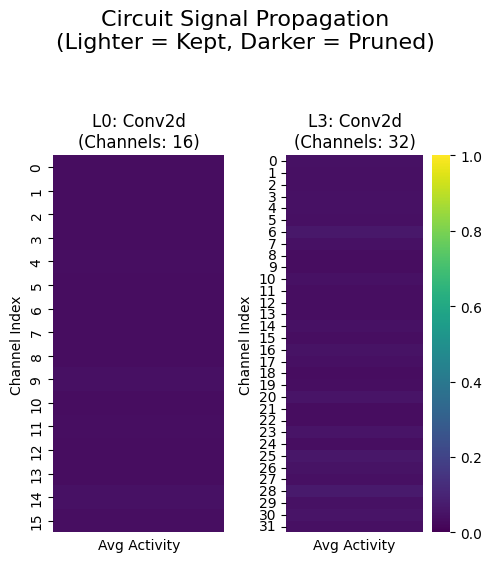


Visualization saved to out/circuit_visualization.png
Saved visualization to: out/circuit_viz_class_8.png
Extracting duplicate 8/10 for class 8
 Processing Class 8 
Configuration: Device=cuda, Lambda=50.0, Dataset=mnist-class-8


/usr/local/lib/python3.12/dist-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/datasets/mnist.py:66: UserWarning: train_labels has been renamed targets
  warnings.warn("train_labels has been renamed targets")
/usr/local/lib/python3.12/dist-packages/torchvision/datasets/mnist.py:71: UserWarning: test_labels has been renamed targets
  warnings.warn("test_labels has been renamed targets")
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 16 worker processes in total. Our suggested max number of worker in current system is 4, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker cr

Calculating mean activations...
Initializing Circuit...
Initializing Optimizer...
Extracting Circuit (L0 Lambda=50.0)...
Epoch 0 | Loss: 12.8197 | Avg Mask: -0.969 | Total Non-Zero: 297.0 | | Circuit Acc: 0.9997
Epoch 1 | Loss: 0.4941 | Avg Mask: -0.987 | Total Non-Zero: 112.0 | | Circuit Acc: 1.0000
Epoch 2 | Loss: 0.2899 | Avg Mask: -0.988 | Total Non-Zero: 73.0 | | Circuit Acc: 1.0000
Epoch 3 | Loss: 0.2451 | Avg Mask: -0.988 | Total Non-Zero: 69.0 | | Circuit Acc: 1.0000
Epoch 4 | Loss: 0.2418 | Avg Mask: -0.988 | Total Non-Zero: 80.0 | | Circuit Acc: 1.0000

--- Visualizing Circuit for Class 8 ---


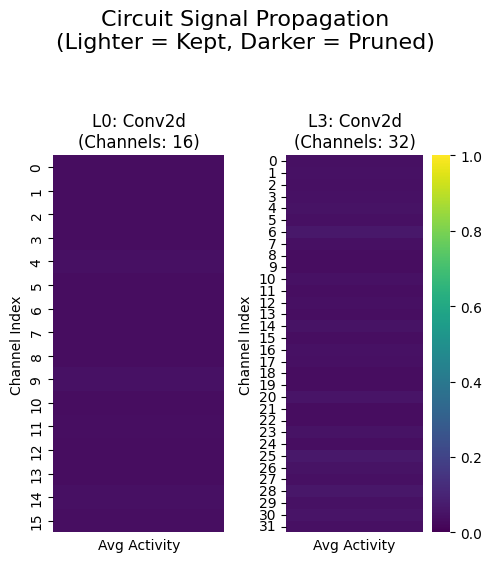


Visualization saved to out/circuit_visualization.png
Saved visualization to: out/circuit_viz_class_8.png
Extracting duplicate 9/10 for class 8
 Processing Class 8 
Configuration: Device=cuda, Lambda=50.0, Dataset=mnist-class-8


/usr/local/lib/python3.12/dist-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/datasets/mnist.py:66: UserWarning: train_labels has been renamed targets
  warnings.warn("train_labels has been renamed targets")
/usr/local/lib/python3.12/dist-packages/torchvision/datasets/mnist.py:71: UserWarning: test_labels has been renamed targets
  warnings.warn("test_labels has been renamed targets")
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 16 worker processes in total. Our suggested max number of worker in current system is 4, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker cr

Calculating mean activations...
Initializing Circuit...
Initializing Optimizer...
Extracting Circuit (L0 Lambda=50.0)...
Epoch 0 | Loss: 12.8476 | Avg Mask: -0.969 | Total Non-Zero: 296.0 | | Circuit Acc: 1.0000
Epoch 1 | Loss: 0.4828 | Avg Mask: -0.989 | Total Non-Zero: 101.0 | | Circuit Acc: 1.0000
Epoch 2 | Loss: 0.2757 | Avg Mask: -0.988 | Total Non-Zero: 70.0 | | Circuit Acc: 1.0000
Epoch 3 | Loss: 0.2499 | Avg Mask: -0.988 | Total Non-Zero: 82.0 | | Circuit Acc: 1.0000
Epoch 4 | Loss: 0.2468 | Avg Mask: -0.988 | Total Non-Zero: 82.0 | | Circuit Acc: 1.0000

--- Visualizing Circuit for Class 8 ---


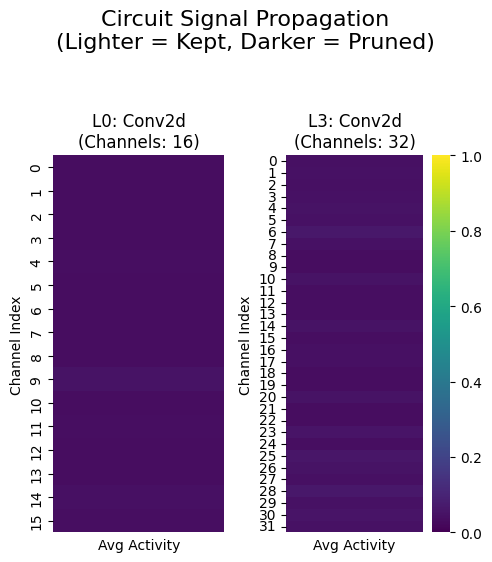


Visualization saved to out/circuit_visualization.png
Saved visualization to: out/circuit_viz_class_8.png
Extracting duplicate 10/10 for class 8
 Processing Class 8 
Configuration: Device=cuda, Lambda=50.0, Dataset=mnist-class-8


/usr/local/lib/python3.12/dist-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/datasets/mnist.py:66: UserWarning: train_labels has been renamed targets
  warnings.warn("train_labels has been renamed targets")
/usr/local/lib/python3.12/dist-packages/torchvision/datasets/mnist.py:71: UserWarning: test_labels has been renamed targets
  warnings.warn("test_labels has been renamed targets")
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 16 worker processes in total. Our suggested max number of worker in current system is 4, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker cr

Calculating mean activations...
Initializing Circuit...
Initializing Optimizer...
Extracting Circuit (L0 Lambda=50.0)...
Epoch 0 | Loss: 12.9407 | Avg Mask: -0.963 | Total Non-Zero: 357.0 | | Circuit Acc: 1.0000
Epoch 1 | Loss: 0.5392 | Avg Mask: -0.988 | Total Non-Zero: 111.0 | | Circuit Acc: 1.0000
Epoch 2 | Loss: 0.2878 | Avg Mask: -0.989 | Total Non-Zero: 73.0 | | Circuit Acc: 1.0000
Epoch 3 | Loss: 0.2441 | Avg Mask: -0.989 | Total Non-Zero: 74.0 | | Circuit Acc: 1.0000
Epoch 4 | Loss: 0.2424 | Avg Mask: -0.988 | Total Non-Zero: 71.0 | | Circuit Acc: 1.0000

--- Visualizing Circuit for Class 8 ---


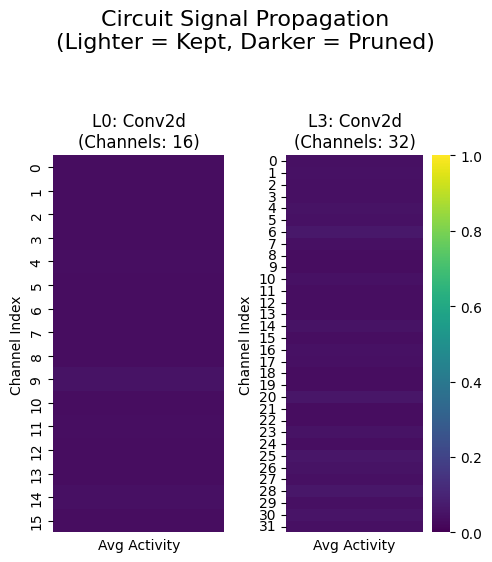


Visualization saved to out/circuit_visualization.png
Saved visualization to: out/circuit_viz_class_8.png


In [97]:
TARGET_REDUNDANCY_CLASS = 8

redundant_circuits = get_n_circuits_same_class(
    model=model,
    class_idx=TARGET_REDUNDANCY_CLASS,
    epochs=5,
    l0_lambda=5e1,
    seed=seed_list[2]
)

redundant_circuits = {f"Run_{i}": c for i, c in enumerate(redundant_circuits)}

In [98]:
red_accs = []
for idx, c in enumerate(redundant_circuits.values()):
    accs = class_wise_acc(c, testloader, classes=[TARGET_REDUNDANCY_CLASS], device=device)
    red_accs.append(accs[TARGET_REDUNDANCY_CLASS])
    print(f"Circuit {idx+1} Accuracy (Class {TARGET_REDUNDANCY_CLASS}): {accs[TARGET_REDUNDANCY_CLASS]:.2%}")

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 16 worker processes in total. Our suggested max number of worker in current system is 4, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


Circuit 1 Accuracy (Class 8): 100.00%
Circuit 2 Accuracy (Class 8): 100.00%
Circuit 3 Accuracy (Class 8): 100.00%
Circuit 4 Accuracy (Class 8): 100.00%
Circuit 5 Accuracy (Class 8): 100.00%
Circuit 6 Accuracy (Class 8): 100.00%
Circuit 7 Accuracy (Class 8): 100.00%
Circuit 8 Accuracy (Class 8): 100.00%
Circuit 9 Accuracy (Class 8): 100.00%
Circuit 10 Accuracy (Class 8): 100.00%


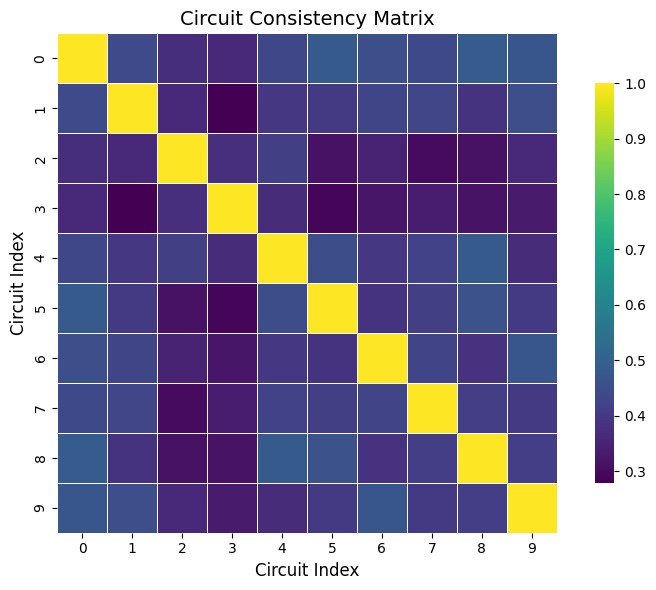

In [99]:
consistency_matrix = circuit_consistency_matrix(list(redundant_circuits.values()), len(redundant_circuits))

visualize_consistency_matrix(consistency_matrix)

In [100]:
red_union = union_circuits(list(redundant_circuits.values()))

union_iso_res = isolation_testing(red_union, trainloader)

union_nec_res = necessity_testing(red_union, trainloader)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 16 worker processes in total. Our suggested max number of worker in current system is 4, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


In [101]:
print(union_iso_res)

{0: 0.00016883336147222692, 1: 0.0, 2: 0.0, 3: 0.0, 4: 0.0, 5: 0.0, 6: 0.0, 7: 0.0, 8: 1.0, 9: 0.0}


In [102]:
print(union_nec_res)

{0: 0.9839608306601384, 1: 0.9894690002966479, 2: 0.743705941591138, 3: 0.7750774751264068, 4: 0.9643957548784663, 5: 0.8714259361741377, 6: 0.9773572152754308, 7: 0.976536312849162, 8: 0.9757306443343018, 9: 0.6327113800638763}


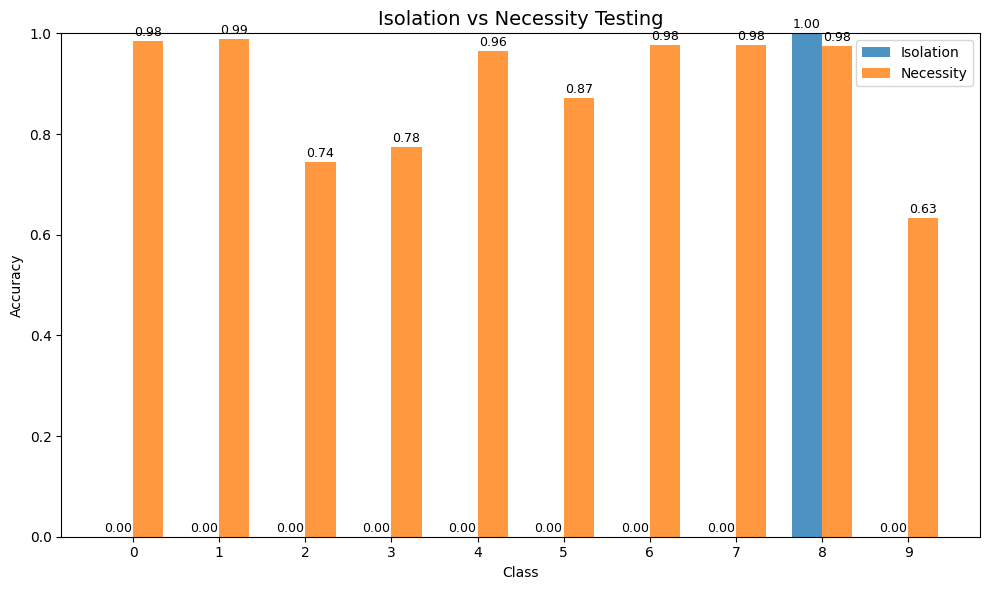

In [103]:
visualize_iso_nec(union_iso_res, union_nec_res)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 16 worker processes in total. Our suggested max number of worker in current system is 4, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


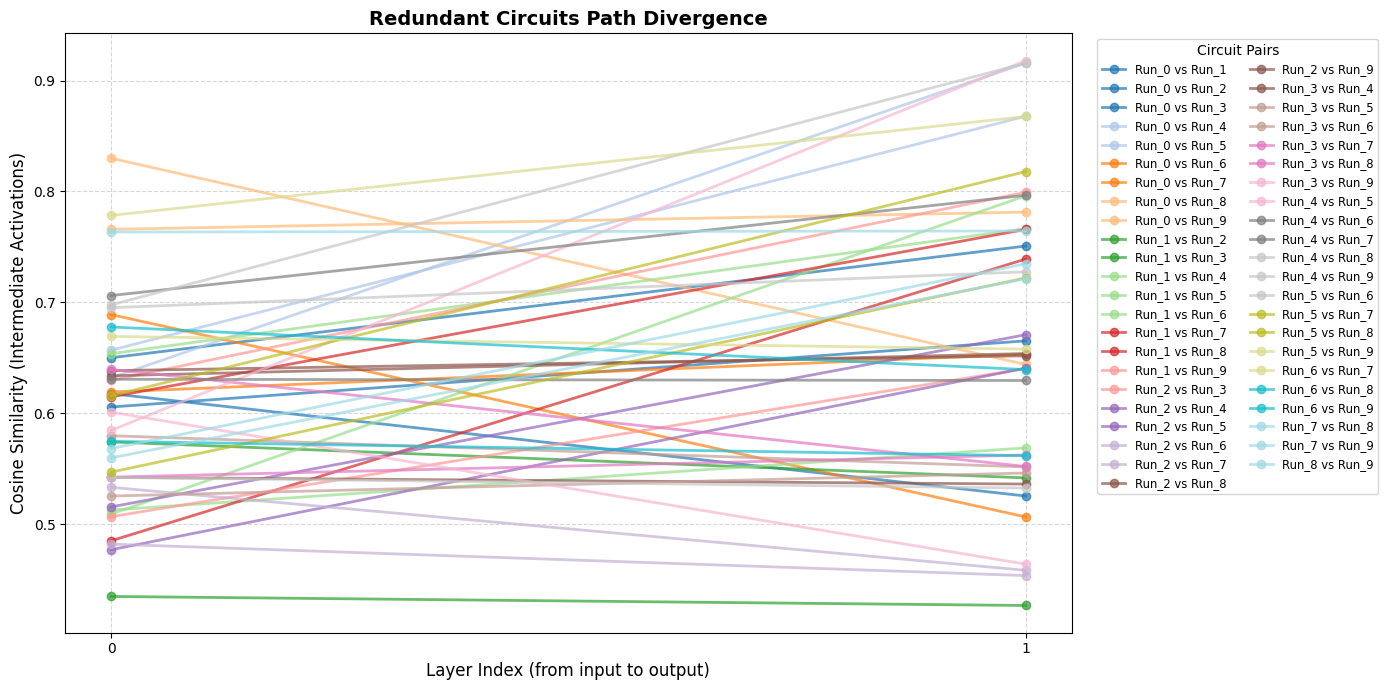

In [104]:
red_divergence_results = path_divergence_dict(
    circuits_dict=redundant_circuits,
    loader=testloader,
    device=device
)

plot_path_divergence_trajectories(red_divergence_results, "out/red_path_div.png", "Redundant Circuits Path Divergence")

Alpha 0.0: Acc Class 8 = 100.00%
Alpha 0.1: Acc Class 8 = 100.00%
Alpha 0.2: Acc Class 8 = 100.00%
Alpha 0.3: Acc Class 8 = 100.00%
Alpha 0.4: Acc Class 8 = 100.00%
Alpha 0.6: Acc Class 8 = 100.00%
Alpha 0.7: Acc Class 8 = 100.00%
Alpha 0.8: Acc Class 8 = 100.00%
Alpha 0.9: Acc Class 8 = 100.00%
Alpha 1.0: Acc Class 8 = 100.00%


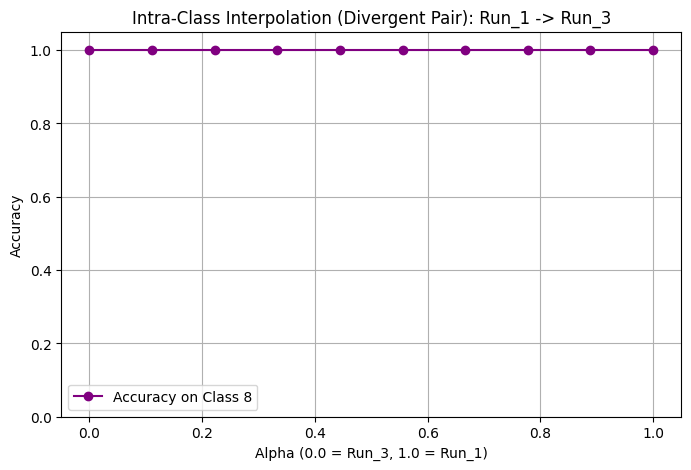

Alpha 0.0: Acc Class 8 = 100.00%
Alpha 0.1: Acc Class 8 = 100.00%
Alpha 0.2: Acc Class 8 = 100.00%
Alpha 0.3: Acc Class 8 = 100.00%
Alpha 0.4: Acc Class 8 = 100.00%
Alpha 0.6: Acc Class 8 = 100.00%
Alpha 0.7: Acc Class 8 = 100.00%
Alpha 0.8: Acc Class 8 = 100.00%
Alpha 0.9: Acc Class 8 = 100.00%
Alpha 1.0: Acc Class 8 = 100.00%


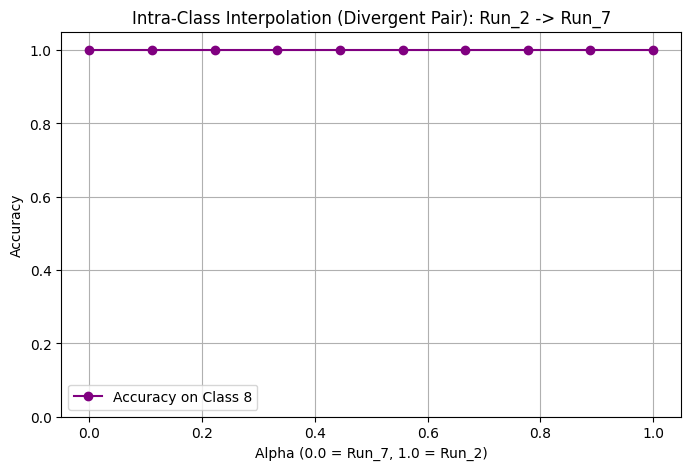

Alpha 0.0: Acc Class 8 = 100.00%
Alpha 0.1: Acc Class 8 = 100.00%
Alpha 0.2: Acc Class 8 = 100.00%
Alpha 0.3: Acc Class 8 = 100.00%
Alpha 0.4: Acc Class 8 = 100.00%
Alpha 0.6: Acc Class 8 = 100.00%
Alpha 0.7: Acc Class 8 = 100.00%
Alpha 0.8: Acc Class 8 = 100.00%
Alpha 0.9: Acc Class 8 = 100.00%
Alpha 1.0: Acc Class 8 = 100.00%


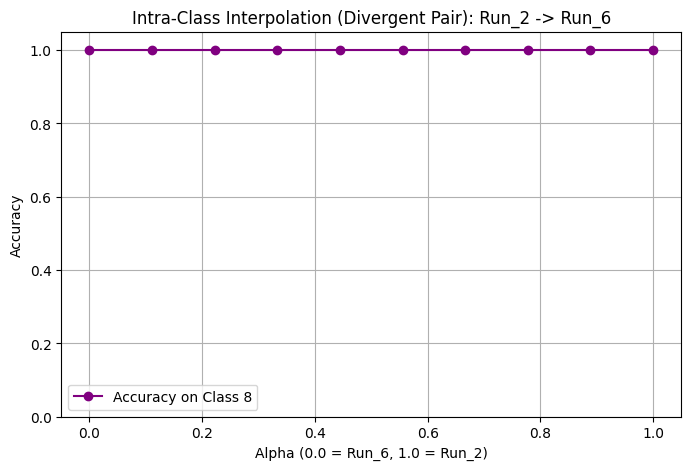

In [105]:
sorted_red_pairs = sorted(red_divergence_results.items(), key=lambda x: x[1][-1])

red_div_interp = [pair[0] for pair in sorted_red_pairs[:3]]

for (run_a, run_b) in red_div_interp:
    # print(f"Interpolating between redundant circuits: {run_a} and {run_b}...")
    interp_circuits = get_interpolated_circuits(
        c_a=redundant_circuits[run_a], 
        c_b=redundant_circuits[run_b], 
        steps=10
    )
    
    alphas = list(interp_circuits.keys())
    acc_list = []
    
    for alpha, interp_c in interp_circuits.items():
        accs = class_wise_acc(interp_c, testloader, classes=[TARGET_REDUNDANCY_CLASS], device=device)
        acc_list.append(accs[TARGET_REDUNDANCY_CLASS])
        print(f"Alpha {alpha:.1f}: Acc Class {TARGET_REDUNDANCY_CLASS} = {accs[TARGET_REDUNDANCY_CLASS]:.2%}")
        
    plt.figure(figsize=(8, 5))
    plt.plot(alphas, acc_list, marker='o', label=f'Accuracy on Class {TARGET_REDUNDANCY_CLASS}', color='purple')
    plt.title(f"Intra-Class Interpolation (Divergent Pair): {run_a} -> {run_b}")
    plt.xlabel(f"Alpha (0.0 = {run_b}, 1.0 = {run_a})")
    plt.ylabel("Accuracy")
    plt.ylim(0, 1.05)
    plt.legend()
    plt.grid(True)
    plt.savefig(f"out/red_interpolation_{run_a}_to_{run_b}.png")
    plt.show()
    plt.close()

### get n circuits same class n models

In [106]:
N_MODELS = 3
TARGET_TEST_CLASS = 3
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

In [107]:
model_config = {
    'lr': 1e-3, 'epochs': 15, 'ds_name': 'mnist-baseline', 
    'device': DEVICE, 'seed': seed_list[3], 'inp_shape': (1, 28, 28), 'num_classes': 10
}
sched = scheduler(start = 2, end= 10, start_sparsity=1, target_sparsity=0.10, alpha=0.15)

In [109]:
mnist_models = train_n_models(N_MODELS, model_config, sched)

n_params 20432 n_params_wd 20432
cuda


/usr/local/lib/python3.12/dist-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


Epoch 0 | Train Acc: 0.9778 | Test Acc: 0.9783
Epoch 1 | Train Acc: 0.9859 | Test Acc: 0.9847
Epoch 2 | Train Acc: 0.9241 | Test Acc: 0.9286
Epoch 3 | Train Acc: 0.9478 | Test Acc: 0.9497
Epoch 4 | Train Acc: 0.9519 | Test Acc: 0.9533
Epoch 5 | Train Acc: 0.9607 | Test Acc: 0.9622
Epoch 6 | Train Acc: 0.9622 | Test Acc: 0.9638
Epoch 7 | Train Acc: 0.9634 | Test Acc: 0.9639
Epoch 8 | Train Acc: 0.9655 | Test Acc: 0.9670
Epoch 9 | Train Acc: 0.9624 | Test Acc: 0.9652
Epoch 10 | Train Acc: 0.9634 | Test Acc: 0.9654
Epoch 11 | Train Acc: 0.9628 | Test Acc: 0.9631
Epoch 12 | Train Acc: 0.9662 | Test Acc: 0.9668
Epoch 13 | Train Acc: 0.9674 | Test Acc: 0.9676
Epoch 14 | Train Acc: 0.9672 | Test Acc: 0.9658
n_params 20432 n_params_wd 20432
cuda
Epoch 0 | Train Acc: 0.9780 | Test Acc: 0.9788
Epoch 1 | Train Acc: 0.9855 | Test Acc: 0.9855
Epoch 2 | Train Acc: 0.9294 | Test Acc: 0.9306
Epoch 3 | Train Acc: 0.9430 | Test Acc: 0.9469
Epoch 4 | Train Acc: 0.9456 | Test Acc: 0.9478
Epoch 5 | Train A

Exception in thread Thread-1201 (_pin_memory_loop):
Traceback (most recent call last):
  File "/usr/lib/python3.12/threading.py", line 1075, in _bootstrap_inner
    self.run()
  File "/usr/lib/python3.12/threading.py", line 1012, in run
    self._target(*self._args, **self._kwargs)
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/pin_memory.py", line 52, in _pin_memory_loop
    do_one_step()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/pin_memory.py", line 28, in do_one_step
    r = in_queue.get(timeout=MP_STATUS_CHECK_INTERVAL)
        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/queues.py", line 122, in get
    return _ForkingPickler.loads(res)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/multiprocessing/reductions.py", line 541, in rebuild_storage_fd
    fd = df.detach()
         ^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/resourc

KeyboardInterrupt: 

In [ ]:
circuits = get_circuits_from_models(
    mnist_models, class_idx=TARGET_TEST_CLASS, epochs=3,
    lr=0.1,
    l0_lambda=5e+1,
    seed=seed_list[4]
)

In [ ]:
circuits_dict = {f"Model_{i}": c for i, c in enumerate(circuits)}
mnist_train, mnist_test = train.load_dataset("mnist-baseline")

In [ ]:
plot_circuit_testing_heatmap(circuits_dict, isolation_testing, mnist_train, dev=DEVICE)

In [ ]:
plot_circuit_testing_heatmap(circuits_dict, necessity_testing, mnist_train, dev=DEVICE)

In [ ]:
cons_matrix = circuit_consistency_matrix(circuits, len(circuits))
visualize_consistency_matrix(cons_matrix, title=f"Consistency Matrix (Class {TARGET_TEST_CLASS})")

In [ ]:
div_dict = path_divergence_dict(circuits_dict, mnist_test, device=DEVICE)
plot_path_divergence_trajectories(div_dict, "out/n_models_path_div.png", f"Path Divergence (Class {TARGET_TEST_CLASS})")

In [ ]:
best_acc = -1
best_idx = 0

for i, c in enumerate(circuits):
    # Test on isolation accuracy for the target class
    accs = isolation_testing(c, mnist_test, classes=[TARGET_TEST_CLASS], dev=DEVICE)
    if accs[TARGET_TEST_CLASS] > best_acc:
        best_acc = accs[TARGET_TEST_CLASS]
        best_idx = i

best_mnist_model = mnist_models[best_idx]
best_mnist_circuit = circuits[best_idx]
print(f"Best Circuit is from Model_{best_idx} with Isolation Acc: {best_acc:.2%}")

### Cross Domain Testing

In [ ]:
color_config = model_config.copy()
color_config['ds_name'] = 'colour-mnist'

In [ ]:
colored_model = train_n_models(1, color_config, seed=seed_list[5])[0]

In [ ]:
color_train, color_test = train.load_dataset("colour-mnist")

In [ ]:
mnist_to_color_results = cross_model_circuit_test(
    src_model=best_mnist_model, 
    target_model=colored_model, 
    target_loader=color_test, 
    class_idx=TARGET_TEST_CLASS, 
    src_circuit=best_mnist_circuit, 
    dev=DEVICE,
    seed=seed_list[6]
)

In [ ]:
color_to_mnist_results = cross_model_circuit_test(
    src_model=colored_model, 
    target_model=best_mnist_model, 
    target_loader=mnist_test, 
    class_idx=TARGET_TEST_CLASS, 
    src_circuit=None, # Will extract automatically
    dev=DEVICE,
    seed=seed_list[7]
)